# Intrusion Detection with Neural Networks (Single Neuron Output w/ sigmoid)

**Author**: Tyler Burguillos, Austin Nolte, Alan Lei, Nishan Majarjan  
**Course**: CSC 180 - Intelligent Systems (Fall 2024)  
**Assignment**: Project 2 - Intrusion Detection  
**Due Date**: October 9, 2024  

Problem Statement

For this project, the goal is to detect network intrusions using the UNSW-NB15 dataset. This involves building both Fully-Connected Neural Networks (FNN) and Convolutional Neural Networks (CNN) to classify network traffic as either normal or malicious. We’ll train our models, tune hyperparameters like optimizers, learning rates, and layer configurations, and evaluate their performance using accuracy, precision, recall, and F1-score. As an additional feature, we will explore class balancing techniques to address class imbalance, aiming to improve the model's ability to correctly identify both normal and attack traffic.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Sequence

# Helper functions from the labs

# One-hot encode text columns using pd.concat() for better performance
def encode_text_dummy(df, name):
  dummies = pd.get_dummies(df[name], prefix=name)
  df = pd.concat([df, dummies], axis=1)
  df.drop(name, axis=1, inplace=True)
  return df

# Z-score normalization for numeric columns
def encode_numeric_zscore(df, name):
  df[name] = (df[name] - df[name].mean()) / df[name].std()

# Convert a Pandas dataframe to the x,y inputs that TensorFlow needs
def to_xy(df, target):
    result = []
    for x in df.columns:
        if x != target:
            result.append(x)
    # find out the type of the target column.
    target_type = df[target].dtypes
    target_type = target_type[0] if isinstance(target_type, Sequence) else target_type
    # Encode to int for classification, float otherwise. TensorFlow likes 32 bits.
    if target_type in (np.int64, np.int32):
        # Classification
        dummies = pd.get_dummies(df[target])
        return df[result].values.astype(np.float32), dummies.values.astype(np.float32)
    else:
        # Regression
        return df[result].values.astype(np.float32), df[target].values.astype(np.float32)

# Encode a column to a range between normalized_low and normalized_high.
def encode_numeric_range(df, name, normalized_low=-1, normalized_high=1,
                         data_low=None, data_high=None):
    if data_low is None:
        data_low = min(df[name])
        data_high = max(df[name])

    df[name] = ((df[name] - data_low) / (data_high - data_low)) \
               * (normalized_high - normalized_low) + normalized_low

# Alan Lei 10/01/2024

## Evaluation Functions:

### Loading and Predicting with the Model

This function will load a model, make predictions, and return the predicte classes and probabilities.

In [ ]:
import tensorflow as tf
import numpy as np

def load_and_predict(model_path, X_test):
  model = tf.keras.models.load_model(model_path)
  y_pred = model.predict(X_test)
  y_pred_classes = np.argmax(y_pred, axis=1) # Convert probabilities to class labels
  return y_pred, y_pred_classes

# Alan Lei 10/06/2024

### Classification Report and Metrics

This function will calculate and print the classification report, and return it in a format for logging purposes.

In [ ]:
from sklearn.metrics import classification_report

def generate_classification_report(y_true, y_pred_classes, target_names):
  report = classification_report(y_true, y_pred_classes, target_names=target_names, output_dict=True)
  print("\nClassificaition Report: \n")
  print(classification_report(y_true, y_pred_classes, target_names=target_names))
  return report

# Austin Nolte 10/06/2024

### Confusion Matrix

This function will plot the confusion matrix.

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred_classes, class_names):
  cm = confusion_matrix(y_true, y_pred_classes)
  print("\n Confusion Matrix:\n", cm, "\n")

  plt.figure(figsize=(6, 6))
  plt.title("Confusion Matrix")
  plt.imshow(cm, interpolation='nearest', cmap=plt.get_cmap('Blues'))
  plt.colorbar()
  tick_marks = np.arange(len(class_names))
  plt.xticks(tick_marks, class_names, rotation=45)
  plt.yticks(tick_marks, class_names)
  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.show()

  return cm

  # Nishan Majarjan 10/06/2024

### ROC Curve and AUC Score

This function will calculate and plot the ROC curve and AUC score.

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc_curve(y_true, y_pred_prob):
  fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
  roc_auc = roc_auc_score(y_true, y_pred_prob)

  plt.figure()
  plt.plot(fpr, tpr, color = 'darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver Operating Characteristic (ROC) Curve')
  plt.legend(loc="lower right")
  plt.show()

  return roc_auc

# Tyler Burguillos 10/06/2024

### Additional Feature: Feature Importance and Class Weighting

In this section, we perform feature importance analysis using logistic regression to identify the top 10 most important features, and apply class weighting to handle the imbalance between the "Normal" and "Attack" classes.

In [ ]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

def feature_importance_analysis(X_train, y_train):
  logreg_model = LogisticRegression(solver='liblinear')
  logreg_model.fit(X_train, y_train)

  # Get feature importance
  importance = logreg_model.coef_[0]

  # Plot feature importance
  plt.bar([x for x in range(len(importance))], importance)
  plt.title("Feature Importance via Logistic Regression")
  plt.show()

  return importance

  # Tyler Burguillos 10/06/2024

### Running the Full Evaluation Process

This function will run the entire evaluation process (loading the model, evaluating metrics, and plotting the ROC curve).

In [ ]:
def evaluate_model(model_path, X_test, y_test, class_names=['Normal', 'Attack']):
  # Load model and make predictions
  y_pred, y_pred_classes = load_and_predict(model_path, X_test)
  y_true = y_test

  # Generate classification report
  report = generate_classification_report(y_true, y_pred_classes, target_names=class_names)

  # Plot confusion matrix
  cm = plot_confusion_matrix(y_true, y_pred_classes, class_names)

  # Plot ROC curve and calculate AUC score
  roc_auc = plot_roc_curve(y_true, y_pred)

  return report, cm, roc_auc

  # Alan Lei 10/06/2024

## Data Loading and Initial Exploration

The following code blocks mount the Google Drive to access the training and test datasets, sets up the file paths, loads the CSV files into pandas DataFrames (`df_train` and `df_test`), and prints the first few rows of both datasets to understand their structure. Finally, it provides a sumary of both datasets, checking for missing values and unusual data types.

In [ ]:
from google.colab import drive
import os
import pandas as pd


# Force Mount Google Drive
drive.mount('/content/drive')

# Set up file paths
path = "/content/drive/My Drive/Project2/"
filename_training = os.path.join(path, "UNSW_NB15_training-set.csv")
filename_test = os.path.join(path, "UNSW_NB15_test-set.csv")

# Load the data
df_train = pd.read_csv(filename_training)
df_test = pd.read_csv(filename_test)

# Take a quick look at the first few rows to understand the structure
print("First few rows of training data:")
df_train.head()

# Tyler Burguillos 10/01/2024

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
First few rows of training data:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [ ]:
# Take a quick look at the first few rows to understand the structure
print("First few rows of test data: ")
df_test.head()

# Tyler Burguillos 10/01/2024

First few rows of test data: 


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [ ]:
# Get a summary of the data to see if there are any missing values or unusual data types
print("Summary of training data: ")
df_train.info()
print("\nSummary of testing data: ")
df_test.info()

# Tyler Burguillos 10/01/2024

Summary of training data: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              17534

### Dropping Rows with Invalid Data in 'Service'

As per the professor's instruction, we treated `'-'` in the `'service'` column as missing data and dropped corresponding rows.

In [ ]:
# Show shapes before dropping '-'
print(f"Shape of Training data before dropping '-': {df_train.shape}")
print(f"Shape of Test data before dropping '-': {df_test.shape}")

# Remove rows with '-' in 'service'
df_train = df_train[df_train['service'] != '-']
df_test = df_test[df_test['service'] != '-']

# Show shapes after dropping '-'
print(f"\nShape of Training data after dropping '-': {df_train.shape}")
print(f"Shape of Test data after dropping '-': {df_test.shape}")

# Tyler Burguillos 10/02/2024

Shape of Training data before dropping '-': (175341, 45)
Shape of Test data before dropping '-': (82332, 45)

Shape of Training data after dropping '-': (81173, 45)
Shape of Test data after dropping '-': (35179, 45)


### Handling Missing Values

After checking the dataset with the `.info()` method, we noticed that the non-null counts for each column matched the total number of entries in both the training and test sets. This showed us that there weren’t any missing values to worry about. Because of this, we decided not to use the `dropna()` function, since there was no need to remove any rows.


In [ ]:
# Show the shapes of the data before filtering
print("\nTraining data shape before filtering:", df_train.shape)
print("Test data shape before filtering:", df_test.shape)

# List of categorical columns we want to process
categorical_columns = ['state', 'proto', 'service', 'attack_cat']
print(f"\nCleaning categorical data from columns: {categorical_columns}")

for column in categorical_columns:
  # Find unique values in training and test sets
  train_unique = set(df_train[column].unique())
  test_unique = set(df_test[column].unique())

  # Find common values
  common_values = train_unique.intersection(test_unique)

  # Identify values that are unique to each set
  train_only = train_unique - common_values
  test_only = test_unique - common_values

  # Check if there are unique values in either training or test set
  if train_only or test_only:
    print(f"\nUnique to training set for {column}: {train_only}")
    print(f"Unique to test set for {column}: {test_only}")
  else:
    print(f"\nNo unique values found for {column}.")

  # Filter out rows with unique values in both datasets
  df_train = df_train[df_train[column].isin(common_values)]
  df_test = df_test[df_test[column].isin(common_values)]

# Show the shapes of the filtered data
print("\nTraining data shape after filtering:", df_train.shape)
print("Test data shape after filtering:", df_test.shape)

# Printing unique values in filtered datasets to ensure that there is no difference between training and test sets
for column in categorical_columns:
  # Check if the unique values in training and test sets match
  if set(df_train[column].unique()) == set(df_test[column].unique()):
    print(f"\nAll values in {column} now match between training and test sets.")
  else:
    print(f"\nMismatch in unique values found for {column} after filtering!")

print(f"\nUnique values in filtered training set for {column}: ", set(df_train[column].unique()))
print(f"Unique values in filtered test set for {column}: ", set(df_test[column].unique()))

# Tyler Burguillos 10/02/2024


Training data shape before filtering: (81173, 45)
Test data shape before filtering: (35179, 45)

Cleaning categorical data from columns: ['state', 'proto', 'service', 'attack_cat']

Unique to training set for state: {'RST'}
Unique to test set for state: {'ACC'}

No unique values found for proto.

No unique values found for service.

Unique to training set for attack_cat: {'Analysis'}
Unique to test set for attack_cat: set()

Training data shape after filtering: (80595, 45)
Test data shape after filtering: (35178, 45)

All values in state now match between training and test sets.

All values in proto now match between training and test sets.

All values in service now match between training and test sets.

All values in attack_cat now match between training and test sets.

Unique values in filtered training set for attack_cat:  {'Generic', 'Backdoor', 'Reconnaissance', 'Exploits', 'DoS', 'Worms', 'Fuzzers', 'Normal'}
Unique values in filtered test set for attack_cat:  {'Generic', 'Back

In [ ]:
# Show the shapes of the data before filtering
print("\nTraining data shape before dropping 'attack_cat':", df_train.shape)
print("Test data shape before dropping 'attack_cat':", df_test.shape)

# Drop the 'attack_cat' column from the dataset
df_train.drop(columns=['attack_cat'], inplace=True)
df_test.drop(columns=['attack_cat'], inplace=True)

# Show the shapes of the data after dropping 'attack_cat'
print("\nTraining data shape after dropping 'attack_cat':", df_train.shape)
print("Test data shape after dropping 'attack_cat':", df_test.shape)

# Check that 'attack_cat' has been removed from the data
print("\nColumns in training data after dropping 'attack_cat':")
print(df_train.columns)

# Tyler Burguillos 10/02/2024


Training data shape before dropping 'attack_cat': (80595, 45)
Test data shape before dropping 'attack_cat': (35178, 45)

Training data shape after dropping 'attack_cat': (80595, 44)
Test data shape after dropping 'attack_cat': (35178, 44)

Columns in training data after dropping 'attack_cat':
Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'label'],
      dtype='object')


### Null Value Check

We also performed a check for null values to ensure no missing data remains in either dataset.

In [ ]:
# Check for null values in the training data
if df_train.isnull().values.any():
  print("Training data has null values.")
else:
  print("Training data has no null values.")

# Check for null values in the training data
if df_test.isnull().values.any():
  print("Test data has null values.")
else:
  print("Test data has no null values.")

# Tyler Burguillos 10/02/2024

Training data has no null values.
Test data has no null values.


### Data Preprocessing Summary

#### Author: Tyler Burguillos

As part of the preprocessing for the UNSW-NB15 dataset, my focus was on checking and cleaning up the categorical columns. I started by loading both the training and test datasets, which each have 45 columns, and confirmed that there were no missing values.

Then, I worked on cleaning the categorical columns:  
- **state**  
- **proto**  
- **service**

The main task was to identify and remove rows with unique categorical values that appeared only in one dataset (either training or test). Additionally, for the `service` column, we were instructed to treat the `'-'` value as missing data, so I dropped the rows where this value appeared.



**Key results:**  
- **Training data** shape after filtering: (81173, 45)  
- **Test data** shape after filtering: (35178, 45)  

Now that the training and test sets are properly aligned, we’re good to go for the next steps, with no mismatches in the categorical data that could mess up the model training.


## Performing one hot encoding on columns (proto, state, service)

Convert all categorical columns (`proto`, `state`, `service`) into numerical form using one-hot encoding.

In [ ]:
# Grabbing (proto, state, service, attack_cat) columns and converting into  numerical form using one-hot encoding.
df_columns_to_encode = ['proto', 'state', 'service']

for col in df_columns_to_encode:
  df_train = encode_text_dummy(df_train, col)

print("Categorical train data after one hot encoding: ")
print(df_train.select_dtypes(include=['bool']).head())
print("\nShape of train data after one hot encoding:", df_train.shape)

# Nishan Maharjan 10/02/2024

Categorical train data after one hot encoding: 
    proto_tcp  proto_udp  state_CON  state_FIN  state_INT  state_REQ  \
3        True      False      False       True      False      False   
11       True      False      False       True      False      False   
15      False       True      False      False       True      False   
17       True      False      False       True      False      False   
21       True      False      False       True      False      False   

    service_dhcp  service_dns  service_ftp  service_ftp-data  service_http  \
3          False        False         True             False         False   
11         False        False        False             False         False   
15         False        False        False             False         False   
17         False        False        False             False          True   
21         False        False        False             False          True   

    service_irc  service_pop3  service_radius  ser

In [ ]:
# Apply one-hot encoding for df_test

for col in df_columns_to_encode:
  df_test = encode_text_dummy(df_test, col)

print("\nCategorical test data after one hot encoding: ")
print(df_test.select_dtypes(include=['bool']).head())
print("\nShape of test data after one hot encoding:", df_test.shape)

# Nishan Maharjan 10/02/2024


Categorical test data after one hot encoding: 
    proto_tcp  proto_udp  state_CON  state_FIN  state_INT  state_REQ  \
35       True      False      False       True      False      False   
40       True      False      False       True      False      False   
45       True      False      False       True      False      False   
49       True      False      False       True      False      False   
72       True      False      False       True      False      False   

    service_dhcp  service_dns  service_ftp  service_ftp-data  service_http  \
35         False        False        False             False          True   
40         False        False        False             False          True   
45         False        False        False             False          True   
49         False        False        False             False          True   
72         False        False        False             False          True   

    service_irc  service_pop3  service_radius  ser

### One-Hot Encoding for Categorical Columns Summary

#### Author: Nishan Maharjan

For my part of the preprocessing, I worked on converting the categorical columns into numbers using one-hot encoding. This method creates new binary columns for each category, making it easier for the model to understand the data.

I focused on these columns:
- **proto**  
- **state**  
- **service**

After encoding, I checked the results to make sure everything looked right by printing the first few rows and confirming the shape of the data.

**Key results:**
- **Training data** shape: (81173, 67)  
- **Test data** shape: (35178, 67)  

Now that the categorical data is ready, we can move on to normalizing the numerical data!

## Normalizing and Preparing for TensorFlow

Normalize all numeric columns to ensure the features are on the same scale using Min-Max normalization.

In [ ]:
# Normalizing the following features
df_values_to_normalize = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst']

for val in df_values_to_normalize:
  # normalize training data
  encode_numeric_range(df_train,val)


  # Normalize test data based on test set
  encode_numeric_range(df_test,val,data_low=df_train[val].min(),data_high=df_train[val].max())

print("\nTraining data after nomalization:\n")
print(df_train[df_values_to_normalize].describe())
print("\nTest data after normalization:\n")
print(df_test[df_values_to_normalize].describe())

# Austin Nolte 10/04/2024


Training data after nomalization:

                dur         spkts         dpkts        sbytes        dbytes  \
count  80595.000000  80595.000000  80595.000000  80595.000000  80595.000000   
mean      -0.970742     -0.995812     -0.996730     -0.997776     -0.998035   
std        0.147980      0.039413      0.024133      0.038215      0.023833   
min       -1.000000     -1.000000     -1.000000     -1.000000     -1.000000   
25%       -1.000000     -0.999792     -1.000000     -0.999998     -1.000000   
50%       -0.999967     -0.999792     -0.999636     -0.999995     -0.999978   
75%       -0.979019     -0.998128     -0.998178     -0.999866     -0.999782   
max        1.000000      1.000000      1.000000      1.000000      1.000000   

               rate          sttl          dttl         sload         dload  \
count  80595.000000  80595.000000  80595.000000  80595.000000  80595.000000   
mean      -0.784052      0.241294     -0.382857     -0.956774     -0.979845   
std        0.34

### Min-Max Normalization for Numerical Columns Summary

#### Author: Austin Nolte

I focused on normalizing the numeric features using Min-Max normalization. This keeps all the values within a [-1, 1] range, which should help the neural network train more smoothly. I chose this method because it prevents large variations in the data, like we saw with Z-score, and it handles outliers better by keeping everything within the same scale.

I applied this to a range of features including packet sizes, rates, and time durations, making sure that the same scaling was applied to both the training and test data for consistentcy.

**Key results:**
- **Training data** succesfully normalized with values between -1 and 1.
- **Test data** normalized using the same min and max values from the training set to avoid potential data leakage.  

Now that the numerical data is ready, we can finish splitting the data and reshaping it for our different models!

## Final Data Review and Reshaping

Perform a final check of the dataset, split the data into `X_train`, `X_test`, `y_train`, and `y_test`, and reshape it for different models (FNN and CNN) as needed.

In [ ]:
# Show a quick overview to confirm all preprocessing has been applied correctly
print("Training data summary after preprocessing:")
print(df_train.describe())

print("Test data summary after preprocessing:")
print(df_test.describe())

# Splitting Data for Neural Networks (FNN & CNN)
print(f"Shape of Training data before XY split: {df_train.shape}")
print(f"\nShape of Test data before XY split: {df_test.shape}")

# Target column ('label' contains 0 for normal, 1 for attack)
target_column = 'label'

# Use professor's helper function to split the dataset into X (features) and y (labels)
X_train, y_train = to_xy(df_train, target_column)
X_test, y_test = to_xy(df_test, target_column)

# Convert y_train and y_test to binary labels if they ate one-hot encoded
if y_train.ndim > 1:
  y_train = np.argmax(y_train, axis=1)
  y_test = np.argmax(y_test, axis=1)

# Print shapes to confirm
print(f"\nShape of X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}, y_test: {y_test.shape}")

# Reshape Data for CNNs
# For CNNs, the input must be 4D: (samples, features, 1, 1)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1, 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_train.shape[1], 1, 1)

# Check the shapes after reshaping
print(f"\nShape of X_train for CNN: {X_train_cnn.shape}")
print(f"Shape of X_test for CNN: {X_test_cnn.shape}")

# Alan Lei 10/05/2024

Training data summary after preprocessing:
                  id           dur         spkts         dpkts        sbytes  \
count   80595.000000  80595.000000  80595.000000  80595.000000  80595.000000   
mean   105050.185297     -0.970742     -0.995812     -0.996730     -0.997776   
std     54484.334193      0.147980      0.039413      0.024133      0.038215   
min         4.000000     -1.000000     -1.000000     -1.000000     -1.000000   
25%     54927.000000     -1.000000     -0.999792     -1.000000     -0.999998   
50%    124963.000000     -0.999967     -0.999792     -0.999636     -0.999995   
75%    151343.500000     -0.979019     -0.998128     -0.998178     -0.999866   
max    175341.000000      1.000000      1.000000      1.000000      1.000000   

             dbytes          rate          sttl          dttl         sload  \
count  80595.000000  80595.000000  80595.000000  80595.000000  80595.000000   
mean      -0.998035     -0.784052      0.241294     -0.382857     -0.956774   

### Final Data Splitting and Reshaping Summary

#### Author: Alan Lei

After normalization, I split the dataset into features (`X_train`, `X_test1) and labels (`y_train` and `y_test`), preparing them for model training. For CNNs, the data needed to be reshaped into 4D format (samples, features,1 ,1), which has been done here.

**Key results:**
- **Training set size:** 80,595 samples, 67 columns.
- **Test set size:** 35,178 samples, 67 columns

The data is now prepped and ready to be passed through both fully-connected and convolutional networks for training and evaluation.

## Model 1 (Generic FNN)

### Setting up Early Stopping and Model Checkpoints

This block defines callbacks for early stopping to prevent overfitting, and model checkpoints to save the best models during Hyperband and Bayesian optimization.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define early stopping to monitor validation loss and stop early if performance stagnates
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Define Model Checkpoints for Bayesian tuning to save the best model to a file
checkpoint_filepath = 'best_model_generic.keras'
model_checkpoint = ModelCheckpoint(checkpoint_filepath, monitor= 'val_loss', save_best_only=True, verbose=1)

# Tyler Burguillos 10/06/2024

### Defining the FNN Model Builder Function

This block contains the core of our tunable fnn model builder, allowing us to experiment with different numbers of units, dropout rate, activation functions, and optimizers. The defaults can be updated based on the results of the tuning.

In [ ]:
!pip install -q -U keras-tuner
import tensorflow as tf
import keras_tuner as kt

def fnn_model_builder_generic(hp):
  fnn_model = tf.keras.Sequential()

  # NOTE: After running these tuning models, we can update the "default" values for each metric to the best values found by our tuners for further testing by all teammates.
  # The average runtime of the hyperband tuner at max_epochs=20 and factor=3 is 30 trials @ 26m 12s
  # The average runtime of the bayesian tuner at max_trials=50 and executions_per_tria=1 is 50 trials @ 01h 55m 32s

  # Tune the number of units
  hp_units = hp.Int('units', min_value=32, max_value=512, step=32, default=448)
  fnn_model.add(tf.keras.layers.Dense(units=hp_units, activation=hp.Choice('activation', values=['relu', 'sigmoid', 'tanh'], default='relu')))

  # Droput rate
  hp_dropout = hp.Float('dropout_rate', min_value=0.0, max_value=0.4, step=0.1, default=0.3)
  fnn_model.add(tf.keras.layers.Dropout(hp_dropout))

  # Add additional layers (if desired)
  hp_hidden_units = hp.Int('hidden_units', min_value=32, max_value=256, step=32, default=128)
  fnn_model.add(tf.keras.layers.Dense(units=hp_hidden_units, activation=hp.Choice('activation', values=['relu', 'sigmoid', 'tanh'], default='relu')))

  fnn_model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
  #fnn_model.add(tf.keras.layers.Dense(2, activation='sigmoid'))

# Tyler Burguillos 10/06/2024

# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------

  # Tune the optimizer type
  hp_optimizer = hp.Choice('optimizer', values=['adam', 'sgd'], default='adam')

  if hp_optimizer == 'adam':
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4], default=1e-3))
  else:
    optimizer = tf.keras.optimizers.SGD(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4], default=1e-3))

  fnn_model.compile(optimizer=optimizer,
                loss='binary_crossentropy',
                metrics=['accuracy'])

  return fnn_model

# Nishan Maharjan 10/06/2024

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.1 MB/s eta 0:00:00


### Bayesian Optimization Tuning

Here we use Bayesian Optimization to refine our model search even further, focusing on finding the most accurate configuration over 50 trials.

In [ ]:
# Setup the Bayesian tuner
bayesian_tuner = kt.BayesianOptimization(
    fnn_model_builder_generic,
    objective='val_accuracy',
    max_trials=30,  # number of different hyperparameter combinations to try
    executions_per_trial=1,
    directory='bayesian_tuning',
    project_name='fnn_tuning_generic'
)

# Run the Bayesian search
bayesian_tuner.search(X_train, y_train, epochs=30, validation_data=(X_test, y_test),
                      callbacks=[early_stopping, model_checkpoint])

# Retrieve the best hyperparameters from Bayesian Optimization
best_hps_bayesian = bayesian_tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Bayesian Optimization found these optimal values: {best_hps_bayesian.values}")

# Austin Nolte 10/06/2024

Trial 5 Complete [00h 01m 30s]
val_accuracy: 0.7264199256896973

Best val_accuracy So Far: 0.7401500940322876
Total elapsed time: 00h 09m 58s
Bayesian Optimization found these optimal values: {'units': 320, 'activation': 'tanh', 'dropout_rate': 0.30000000000000004, 'hidden_units': 96, 'optimizer': 'adam', 'learning_rate': 0.0001}


### Evaluating the FNN Best Generic Model

In these blocks, we load the best model from the Bayesian search and evaluate its performance on the test data to see how it performed

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m


Classificaition Report: 

              precision    recall  f1-score   support

      Normal       0.27      1.00      0.43      9624
      Attack       0.00      0.00      0.00     25554

    accuracy                           0.27     35178
   macro avg       0.14      0.50      0.21     35178
weighted avg       0.07      0.27      0.12     35178


 Confusion Matrix:
 [[ 9624     0]
 [25554     0]] 



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


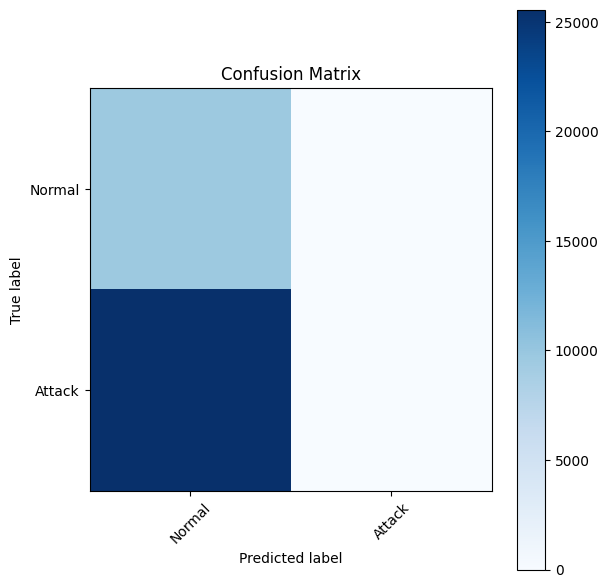

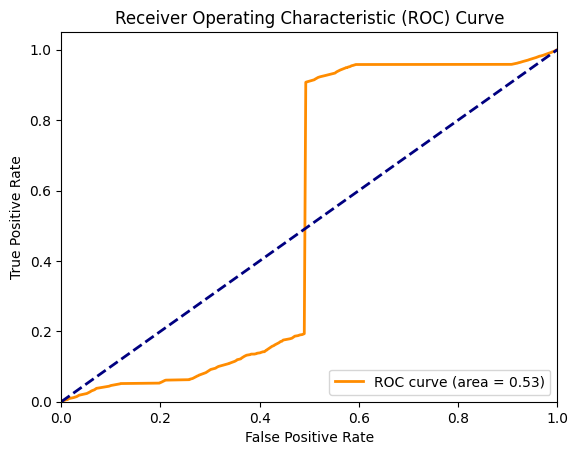

In [ ]:
# Evaluate an generate metrics using our `evaluate_model` function

report, cm, roc_auc = evaluate_model('best_model_generic.keras', X_test, y_test, class_names=['Normal', 'Attack'])

# Tyler Burguillos 10/06/2024

## Model 2 (ReLU FNN)

### Setting up Early Stopping and Model Checkpoints

This block defines callbacks for early stopping to prevent overfitting, and model checkpoints to save the best models during Hyperband and Bayesian optimization.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define early stopping to monitor validation loss and stop early if performance stagnates
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Define Model Checkpoints for Bayesian tuning to save the best model to a file
checkpoint_filepath = 'best_model_relu.keras'
model_checkpoint = ModelCheckpoint(checkpoint_filepath, monitor= 'val_loss', save_best_only=True, verbose=1)

# Tyler Burguillos 10/06/2024

### Defining the FNN Model Builder Function

This block contains the core of our tunable fnn model builder, allowing us to experiment with different numbers of units, dropout rate, activation functions, and optimizers. The defaults can be updated based on the results of the tuning.

In [ ]:
!pip install -q -U keras-tuner
import tensorflow as tf
import keras_tuner as kt

def fnn_model_builder_relu(hp):
  fnn_model = tf.keras.Sequential()

  # NOTE: After running these tuning models, we can update the "default" values for each metric to the best values found by our tuners for further testing by all teammates.
  # The average runtime of the hyperband tuner at max_epochs=20 and factor=3 is 30 trials @ 26m 12s
  # The average runtime of the bayesian tuner at max_trials=50 and executions_per_tria=1 is 50 trials @ 01h 55m 32s

  # Tune the number of units
  hp_units = hp.Int('units', min_value=32, max_value=512, step=32, default=448)
  fnn_model.add(tf.keras.layers.Dense(units=hp_units, activation='relu'))

  # Droput rate
  hp_dropout = hp.Float('dropout_rate', min_value=0.0, max_value=0.4, step=0.1, default=0.3)
  fnn_model.add(tf.keras.layers.Dropout(hp_dropout))

  # Add additional layers (if desired)
  hp_hidden_units = hp.Int('hidden_units', min_value=32, max_value=256, step=32, default=128)
  fnn_model.add(tf.keras.layers.Dense(units=hp_hidden_units, activation='relu'))

  fnn_model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
  #fnn_model.add(tf.keras.layers.Dense(2, activation='sigmoid'))

# Tyler Burguillos 10/06/2024

# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------

  # Tune the optimizer type
  hp_optimizer = hp.Choice('optimizer', values=['adam', 'sgd'], default='adam')

  if hp_optimizer == 'adam':
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4], default=1e-3))
  else:
    optimizer = tf.keras.optimizers.SGD(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4], default=1e-3))

  fnn_model.compile(optimizer=optimizer,
                loss='binary_crossentropy',
                metrics=['accuracy'])

  return fnn_model

# Nishan Maharjan 10/06/2024

### Bayesian Optimization Tuning

Here we use Bayesian Optimization to refine our model search even further, focusing on finding the most accurate configuration over 50 trials.

In [ ]:
# Setup the Bayesian tuner
bayesian_tuner = kt.BayesianOptimization(
    fnn_model_builder_relu,
    objective='val_accuracy',
    max_trials=30,  # number of different hyperparameter combinations to try
    executions_per_trial=1,
    directory='bayesian_tuning',
    project_name='fnn_tuning_relu'
)

# Run the Bayesian search
bayesian_tuner.search(X_train, y_train, epochs=30, validation_data=(X_test, y_test),
                      callbacks=[early_stopping, model_checkpoint])

# Retrieve the best hyperparameters from Bayesian Optimization
best_hps_bayesian = bayesian_tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Bayesian Optimization found these optimal values: {best_hps_bayesian.values}")

# Austin Nolte 10/06/2024

Trial 5 Complete [00h 00m 57s]
val_accuracy: 0.6915686130523682

Best val_accuracy So Far: 0.7264199256896973
Total elapsed time: 00h 15m 08s
Bayesian Optimization found these optimal values: {'units': 32, 'activation': 'relu', 'dropout_rate': 0.0, 'hidden_units': 64, 'optimizer': 'adam', 'learning_rate': 0.001}


### Evaluating the FNN Best reLU Model

In these blocks, we load the best model from the Bayesian search and evaluate its performance on the test data to see how it performed

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m


Classificaition Report: 

              precision    recall  f1-score   support

      Normal       0.27      1.00      0.43      9624
      Attack       0.00      0.00      0.00     25554

    accuracy                           0.27     35178
   macro avg       0.14      0.50      0.21     35178
weighted avg       0.07      0.27      0.12     35178



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 Confusion Matrix:
 [[ 9624     0]
 [25554     0]] 



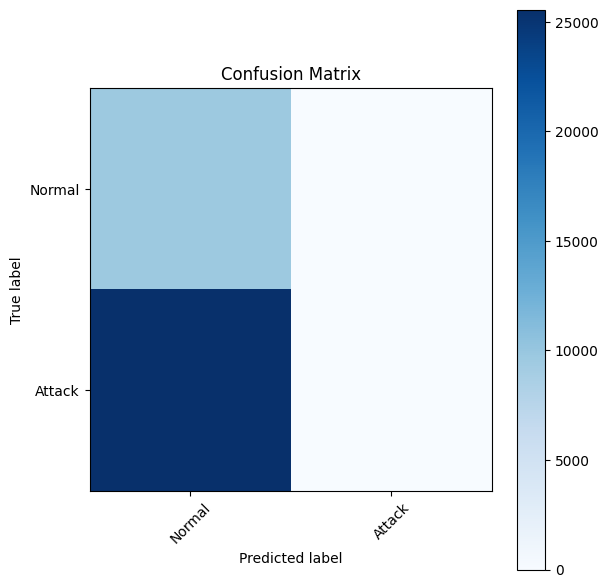

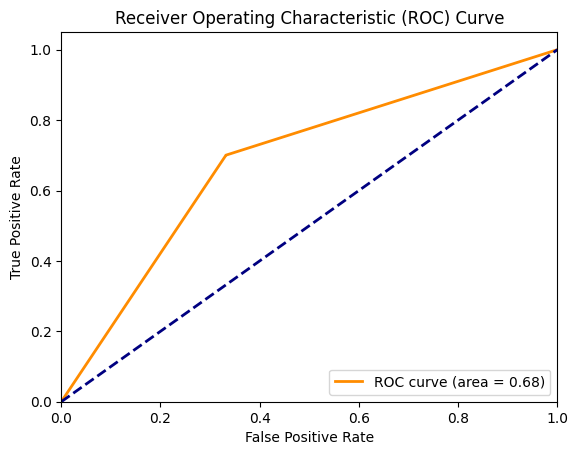

In [ ]:
# Evaluate an generate metrics using our `evaluate_model` function

report, cm, roc_auc = evaluate_model('best_model_relu.keras', X_test, y_test, class_names=['Normal', 'Attack'])

# Tyler Burguillos 10/06/2024

## Model 3 (Sigmoid FNN)

### Setting up Early Stopping and Model Checkpoints

This block defines callbacks for early stopping to prevent overfitting, and model checkpoints to save the best models during Hyperband and Bayesian optimization.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define early stopping to monitor validation loss and stop early if performance stagnates
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Define Model Checkpoints for Bayesian tuning to save the best model to a file
checkpoint_filepath = 'best_model_sigmoid.keras'
model_checkpoint = ModelCheckpoint(checkpoint_filepath, monitor= 'val_loss', save_best_only=True, verbose=1)

# Tyler Burguillos 10/06/2024

### Defining the FNN Model Builder Function

This block contains the core of our tunable fnn model builder, allowing us to experiment with different numbers of units, dropout rate, activation functions, and optimizers. The defaults can be updated based on the results of the tuning.

In [ ]:
!pip install -q -U keras-tuner
import tensorflow as tf
import keras_tuner as kt

def fnn_model_builder_sigmoid(hp):
  fnn_model = tf.keras.Sequential()

  # NOTE: After running these tuning models, we can update the "default" values for each metric to the best values found by our tuners for further testing by all teammates.
  # The average runtime of the hyperband tuner at max_epochs=20 and factor=3 is 30 trials @ 26m 12s
  # The average runtime of the bayesian tuner at max_trials=50 and executions_per_tria=1 is 50 trials @ 01h 55m 32s

  # Tune the number of units
  hp_units = hp.Int('units', min_value=32, max_value=512, step=32, default=448)
  fnn_model.add(tf.keras.layers.Dense(units=hp_units, activation='sigmoid'))

  # Droput rate
  hp_dropout = hp.Float('dropout_rate', min_value=0.0, max_value=0.4, step=0.1, default=0.3)
  fnn_model.add(tf.keras.layers.Dropout(hp_dropout))

  # Add additional layers (if desired)
  hp_hidden_units = hp.Int('hidden_units', min_value=32, max_value=256, step=32, default=128)
  fnn_model.add(tf.keras.layers.Dense(units=hp_hidden_units, activation='sigmoid'))

  fnn_model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
  #fnn_model.add(tf.keras.layers.Dense(2, activation='sigmoid'))

# Tyler Burguillos 10/06/2024

# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------

  # Tune the optimizer type
  hp_optimizer = hp.Choice('optimizer', values=['adam', 'sgd'], default='adam')

  if hp_optimizer == 'adam':
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4], default=1e-3))
  else:
    optimizer = tf.keras.optimizers.SGD(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4], default=1e-3))

  fnn_model.compile(optimizer=optimizer,
                loss='binary_crossentropy',
                metrics=['accuracy'])

  return fnn_model

# Nishan Maharjan 10/06/2024

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.7 MB/s eta 0:00:00


### Bayesian Optimization Tuning

Here we use Bayesian Optimization to refine our model search even further, focusing on finding the most accurate configuration over 50 trials.

In [ ]:
# Setup the Bayesian tuner
bayesian_tuner = kt.BayesianOptimization(
    fnn_model_builder_sigmoid,
    objective='val_accuracy',
    max_trials=30,  # number of different hyperparameter combinations to try
    executions_per_trial=1,
    directory='bayesian_tuning',
    project_name='fnn_tuning_sigmoid'
)

# Run the Bayesian search
bayesian_tuner.search(X_train, y_train, epochs=30, validation_data=(X_test, y_test),
                      callbacks=[early_stopping, model_checkpoint])

# Retrieve the best hyperparameters from Bayesian Optimization
best_hps_bayesian = bayesian_tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Bayesian Optimization found these optimal values: {best_hps_bayesian.values}")

# Austin Nolte 10/06/2024

Trial 30 Complete [00h 00m 47s]
val_accuracy: 0.7264199256896973

Best val_accuracy So Far: 0.7264199256896973
Total elapsed time: 00h 47m 45s
Bayesian Optimization found these optimal values: {'units': 288, 'dropout_rate': 0.0, 'hidden_units': 192, 'optimizer': 'sgd', 'learning_rate': 0.0001}


### Evaluating the FNN Best Sigmoid Model

In these blocks, we load the best model from the Bayesian search and evaluate its performance on the test data to see how it performed

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m


Classificaition Report: 

              precision    recall  f1-score   support

      Normal       0.27      1.00      0.43      9624
      Attack       0.00      0.00      0.00     25554

    accuracy                           0.27     35178
   macro avg       0.14      0.50      0.21     35178
weighted avg       0.07      0.27      0.12     35178


 Confusion Matrix:
 [[ 9624     0]
 [25554     0]] 



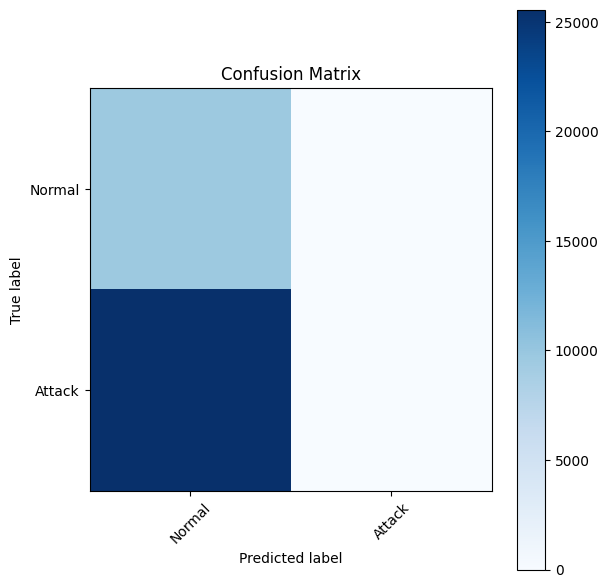

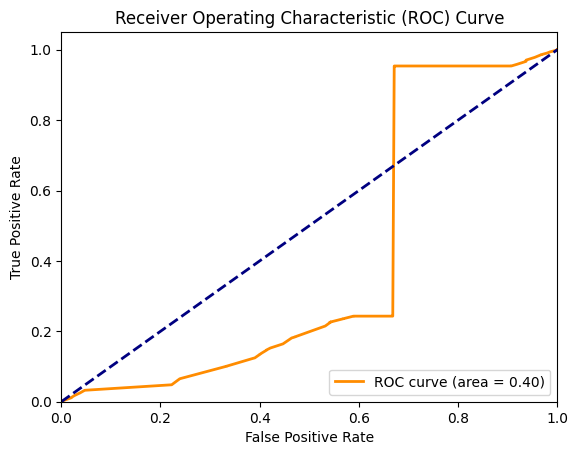

In [ ]:
# Evaluate an generate metrics using our `evaluate_model` function

report, cm, roc_auc = evaluate_model('best_model_sigmoid.keras', X_test, y_test, class_names=['Normal', 'Attack'])

# Tyler Burguillos 10/06/2024

## Model 4 (Tanh FNN)

### Setting up Early Stopping and Model Checkpoints

This block defines callbacks for early stopping to prevent overfitting, and model checkpoints to save the best models during Hyperband and Bayesian optimization.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define early stopping to monitor validation loss and stop early if performance stagnates
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Define Model Checkpoints for Bayesian tuning to save the best model to a file
checkpoint_filepath = 'best_model_tanh.keras'
model_checkpoint = ModelCheckpoint(checkpoint_filepath, monitor= 'val_loss', save_best_only=True, verbose=1)

# Tyler Burguillos 10/06/2024

### Defining the FNN Model Builder Function

This block contains the core of our tunable fnn model builder, allowing us to experiment with different numbers of units, dropout rate, activation functions, and optimizers. The defaults can be updated based on the results of the tuning.

In [ ]:
!pip install -q -U keras-tuner
import tensorflow as tf
import keras_tuner as kt

def fnn_model_builder_tanh(hp):
  fnn_model = tf.keras.Sequential()

  # NOTE: After running these tuning models, we can update the "default" values for each metric to the best values found by our tuners for further testing by all teammates.
  # The average runtime of the hyperband tuner at max_epochs=20 and factor=3 is 30 trials @ 26m 12s
  # The average runtime of the bayesian tuner at max_trials=50 and executions_per_tria=1 is 50 trials @ 01h 55m 32s

  # Tune the number of units
  hp_units = hp.Int('units', min_value=32, max_value=512, step=32, default=448)
  fnn_model.add(tf.keras.layers.Dense(units=hp_units, activation='tanh'))

  # Droput rate
  hp_dropout = hp.Float('dropout_rate', min_value=0.0, max_value=0.4, step=0.1, default=0.3)
  fnn_model.add(tf.keras.layers.Dropout(hp_dropout))

  # Add additional layers (if desired)
  hp_hidden_units = hp.Int('hidden_units', min_value=32, max_value=256, step=32, default=128)
  fnn_model.add(tf.keras.layers.Dense(units=hp_hidden_units, activation='tanh'))

  fnn_model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
  #fnn_model.add(tf.keras.layers.Dense(2, activation='sigmoid'))

# Tyler Burguillos 10/06/2024

# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------

  # Tune the optimizer type
  hp_optimizer = hp.Choice('optimizer', values=['adam', 'sgd'], default='adam')

  if hp_optimizer == 'adam':
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4], default=1e-3))
  else:
    optimizer = tf.keras.optimizers.SGD(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4], default=1e-3))

  fnn_model.compile(optimizer=optimizer,
                loss='binary_crossentropy',
                metrics=['accuracy'])

  return fnn_model

# Nishan Maharjan 10/06/2024

### Bayesian Optimization Tuning

Here we use Bayesian Optimization to refine our model search even further, focusing on finding the most accurate configuration over 50 trials.

In [ ]:
# Setup the Bayesian tuner
bayesian_tuner = kt.BayesianOptimization(
    fnn_model_builder_sigmoid,
    objective='val_accuracy',
    max_trials=30,  # number of different hyperparameter combinations to try
    executions_per_trial=1,
    directory='bayesian_tuning',
    project_name='fnn_tuning_tanh'
)

# Run the Bayesian search
bayesian_tuner.search(X_train, y_train, epochs=30, validation_data=(X_test, y_test),
                      callbacks=[early_stopping, model_checkpoint])

# Retrieve the best hyperparameters from Bayesian Optimization
best_hps_bayesian = bayesian_tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Bayesian Optimization found these optimal values: {best_hps_bayesian.values}")

# Austin Nolte 10/06/2024

### Evaluating the FNN Best Model

In these blocks, we load the best model from the Bayesian search and evaluate its performance on the test data to see how it performed

In [ ]:
# Evaluate an generate metrics using our `evaluate_model` function

report, cm, roc_auc = evaluate_model('best_model_tanh.keras', X_test, y_test, class_names=['Normal', 'Attack'])

# Tyler Burguillos 10/06/2024

## Model 5 (Best FNN + Additional Feature)

### Setting up Early Stopping and Model Checkpoints

This block defines callbacks for early stopping to prevent overfitting, and model checkpoints to save the best models during Hyperband and Bayesian optimization.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define early stopping to monitor validation loss and stop early if performance stagnates
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Define Model Checkpoints for Bayesian tuning to save the best model to a file
checkpoint_filepath = 'best_model.keras'
model_checkpoint = ModelCheckpoint(checkpoint_filepath, monitor= 'val_loss', save_best_only=True, verbose=1)

# Tyler Burguillos 10/06/2024

### Defining the FNN Model Builder Function

This block contains the core of our tunable fnn model builder, allowing us to experiment with different numbers of units, dropout rate, activation functions, and optimizers. The defaults can be updated based on the results of the tuning.

In [ ]:
!pip install -q -U keras-tuner
import tensorflow as tf
import keras_tuner as kt

def fnn_model_builder_best(hp):
  fnn_model = tf.keras.Sequential()

  # NOTE: After running these tuning models, we can update the "default" values for each metric to the best values found by our tuners for further testing by all teammates.
  # The average runtime of the hyperband tuner at max_epochs=20 and factor=3 is 30 trials @ 26m 12s
  # The average runtime of the bayesian tuner at max_trials=50 and executions_per_tria=1 is 50 trials @ 01h 55m 32s

  # Tune the number of units
  hp_units = hp.Int('units', min_value=32, max_value=512, step=32, default=448)
  fnn_model.add(tf.keras.layers.Dense(units=hp_units, activation=hp.Choice('activation', values=['relu', 'sigmoid', 'tanh'], default='relu')))

  # Droput rate
  hp_dropout = hp.Float('dropout_rate', min_value=0.0, max_value=0.4, step=0.1, default=0.3)
  fnn_model.add(tf.keras.layers.Dropout(hp_dropout))

  # Add additional layers (if desired)
  hp_hidden_units = hp.Int('hidden_units', min_value=32, max_value=256, step=32, default=128)
  fnn_model.add(tf.keras.layers.Dense(units=hp_hidden_units, activation=hp.Choice('activation', values=['relu', 'sigmoid', 'tanh'], default='relu')))

  fnn_model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
  #fnn_model.add(tf.keras.layers.Dense(2, activation='sigmoid'))

# Tyler Burguillos 10/06/2024

# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------

  # Tune the optimizer type
  hp_optimizer = hp.Choice('optimizer', values=['adam', 'sgd'], default='adam')

  if hp_optimizer == 'adam':
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4], default=1e-3))
  else:
    optimizer = tf.keras.optimizers.SGD(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4], default=1e-3))

  fnn_model.compile(optimizer=optimizer,
                loss='binary_crossentropy',
                metrics=['accuracy'])

  return fnn_model

# Nishan Maharjan 10/06/2024

### Bayesian Optimization Tuning

Here we use Bayesian Optimization to refine our model search even further, focusing on finding the most accurate configuration over 50 trials.

In [ ]:
# Setup the Bayesian tuner
bayesian_tuner = kt.BayesianOptimization(
    fnn_model_builder_best,
    objective='val_accuracy',
    max_trials=30,  # number of different hyperparameter combinations to try
    executions_per_trial=1,
    directory='bayesian_tuning',
    project_name='fnn_tuning_best'
)

# Run the Bayesian search
bayesian_tuner.search(X_train, y_train, epochs=30, validation_data=(X_test, y_test),
                      callbacks=[early_stopping, model_checkpoint])

# Retrieve the best hyperparameters from Bayesian Optimization
best_hps_bayesian = bayesian_tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Bayesian Optimization found these optimal values: {best_hps_bayesian.values}")

# Austin Nolte 10/06/2024

Trial 1 Complete [00h 01m 41s]
val_accuracy: 0.27403491735458374

Best val_accuracy So Far: 0.27403491735458374
Total elapsed time: 00h 01m 41s
Bayesian Optimization found these optimal values: {'units': 32, 'activation': 'relu', 'dropout_rate': 0.1, 'hidden_units': 224, 'optimizer': 'sgd', 'learning_rate': 0.001}


### Evaluating the FNN Best Overall Model

In these blocks, we load the best model from the Bayesian search and evaluate its performance on the test data to see how it performed

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m


Classificaition Report: 

              precision    recall  f1-score   support

      Normal       0.27      1.00      0.43      9624
      Attack       0.00      0.00      0.00     25554

    accuracy                           0.27     35178
   macro avg       0.14      0.50      0.21     35178
weighted avg       0.07      0.27      0.12     35178


 Confusion Matrix:
 [[ 9624     0]
 [25554     0]] 



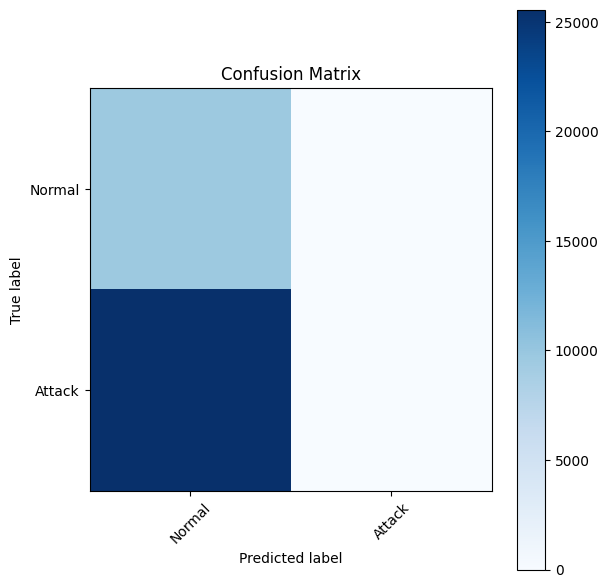

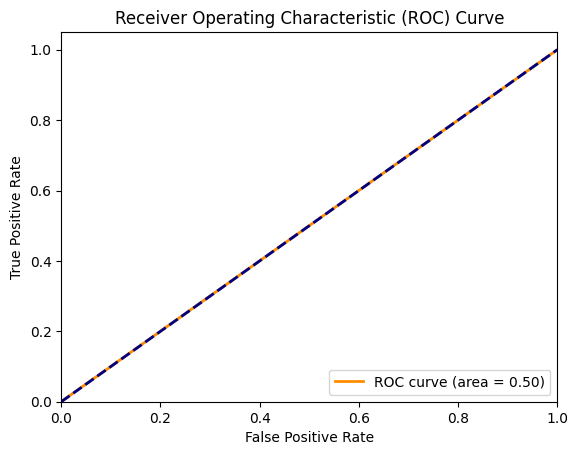

In [ ]:
# Evaluate an generate metrics using our `evaluate_model` function

report, cm, roc_auc = evaluate_model('best_model.keras', X_test, y_test, class_names=['Normal', 'Attack'])

# Tyler Burguillos 10/06/2024

### Additional Feature: Feature Importance and Class Weighting

In this section, we perform feature importance analysis using logistic regression to identify the top 10 most important features, and apply class weighting to handle the imbalance between the "Normal" and "Attack" classes.

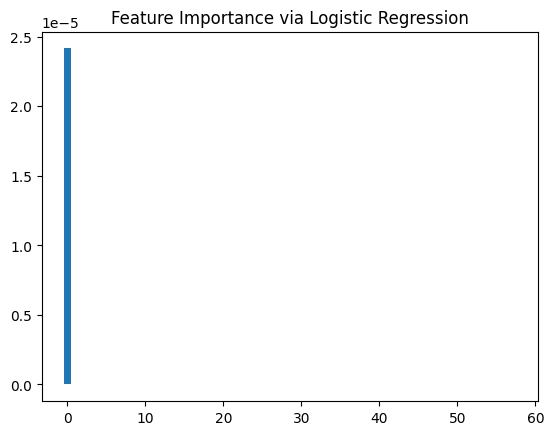

Shape of reduced X_train: (80595, 10)
Shape of reduced X_test: (35178, 10)


In [ ]:
# Perform feature importance analysis and dataset reduction
importance = feature_importance_analysis(X_train, y_train)

# Select top 10 features based on importance
top_features_idx = np.argsort(np.abs(importance))[-10:]
X_train_reduced = X_train[:, top_features_idx]
X_test_reduced = X_test[:, top_features_idx]

print(f"Shape of reduced X_train: {X_train_reduced.shape}")
print(f"Shape of reduced X_test: {X_test_reduced.shape}")

# Tyler Burguillos 10/06/2024

In [ ]:
# Setup the Bayesian tuner with a new directory to avoid loading old results
bayesian_tuner = kt.BayesianOptimization(
    fnn_model_builder_best,
    objective='val_accuracy',
    max_trials=30,  # number of different hyperparameter combinations to try
    executions_per_trial=1,
    directory='bayesian_tuning_logical_regression',
    project_name='fnn_tuning_best'
)

# Run the Bayesian search with the reduced dataset
bayesian_tuner.search(X_train_reduced, y_train, epochs=30, validation_data=(X_test_reduced, y_test),
                      callbacks=[early_stopping, model_checkpoint])

# Retrieve the best hyperparameters from Bayesian Optimization
best_hps_bayesian = bayesian_tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Bayesian Optimization found these optimal values: {best_hps_bayesian.values}")

# Austin Nolte 10/06/2024

Trial 5 Complete [00h 01m 08s]
val_accuracy: 0.7264199256896973

Best val_accuracy So Far: 0.726476788520813
Total elapsed time: 00h 07m 02s
Bayesian Optimization found these optimal values: {'units': 480, 'activation': 'relu', 'dropout_rate': 0.30000000000000004, 'hidden_units': 128, 'optimizer': 'adam', 'learning_rate': 0.001}


#### Bayesian Optimization Experimentation Results:

Please input your experimentation results here in the following format so we can narrow down our best model over multiple runs:

| **Experiment** | **Run by** | **Best val_accuracy** | **Units** | **Activation** | **Dropout Rate** | **Hidden Units** | **Optimizer** | **Learning Rate** | **Max Trials** | Executions Per Trial |
|-|-|-|-|-|-|-|-|-|-|-|
| 0 | Tyler | 0.8057734966278076 | 32 | tanh | 0.2 | 32 | sgd | 0.001 | 50 | 2 |



## Model 6 (Generic CNN):

### Setting up Early Stopping and Model Checkpoints

Reuse the early stopping and checkpoint logic from FNN but customise callbacks based on the CNN performance.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Defining early stopping and model checkpoint
early_stopping_cnn = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_checkpoint_cnn = ModelCheckpoint(filepath='best_cnn_model_relu.keras', monitor= 'val_loss', save_best_only=True, verbose=1)

# Austin Nolte 10/07/2024

### Defining the CNN Model Builder Function

Build a CNN model architecture with convolutional layers, pooling layers, and fully connected layers.

Specify hyperparameters for CNN layers such as:

- Number of filters.
- Kernel size.
- Pooling size.
- Activation functions.
- Dropout layers.

In [ ]:
!pip install -q -U keras-tuner
import tensorflow as tf
import keras_tuner as kt

def cnn_model_buidler_generic(hp):

  cnn = tf.keras.Sequential()

  # Tuning number of filters in conv2d layer
  hp_conv2d_units = hp.Int('units',min_value=16,max_value=512,step=16)

  cnn.add(tf.keras.layers.Conv2D(filters=hp_conv2d_units,kernel_size=(3,1),strides=(1,1),
                                 activation=hp.Choice('activation', values=['relu', 'sigmoid', 'tanh'], default='relu'),padding='same',input_shape=(58,1,1)))

  # Tune pooliing size manually! It causes crashing when using keras to do it automatically
  cnn.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 1), strides=(2, 1)))

  # Dropout rate
  hp_dropout = hp.Float('dropout_rate',min_value=0.0,max_value=0.5,step=0.05,default=0.0)
  cnn.add(tf.keras.layers.Dropout(hp_dropout))

  # Flatten before getting to dense layers
  cnn.add(tf.keras.layers.Flatten())

  # Tuning numbers of units
  hp_units = hp.Int('units', min_value=32, max_value=512,step=32)
  cnn.add(tf.keras.layers.Dense(units=hp_units,activation='relu'))

  # For adding additional layers
  hp_hidden_layers = hp.Int('hidden_units',min_value=32,max_value=256,step=32,default=32)
  cnn.add(tf.keras.layers.Dense(units=hp_hidden_layers, activation=hp.Choice('activation', values=['relu', 'sigmoid', 'tanh'], default='relu')))

  # Output Layer
  cnn.add(tf.keras.layers.Dense(1,activation='relu'))

  # Tune the optimizer type
  hp_optimizer = hp.Choice('optimizer', values=['adam', 'sgd'], default='adam')

  hp_learning_rate = hp.Choice('learning_rate',values=[1e-2,1e-3,1e-4])

  if hp_optimizer == 'adam':
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)
  else:
    optimizer = tf.keras.optimizers.SGD(learning_rate=hp_learning_rate)

  cnn.compile(optimizer=optimizer,loss=tf.keras.losses.binary_crossentropy,metrics=['accuracy'])

  return cnn

# Austin Nolte 10/07/24

### Bayesian Optimization Tuning

Adapt the Bayesian optimization setup to handle CNN-specific hyperparameters, such as:

- Number of filters (for convolutional layers).
- Kernel size (for convolutional layers).
- Pooling size (for pooling layers).
- Dropout rate (for regulaization).

In [ ]:
# Making Bayesian tuner

tuner = kt.BayesianOptimization(
    cnn_model_buidler_generic,
    objective='val_accuracy',
    max_trials=30, # 5 for testing, 30 for normal
    executions_per_trial=1,
    directory='bayesian_tuning_cnn',
    project_name='cnn_tuning_generic'
)

tuner.search(X_train_cnn,y_train,epochs=30,validation_data=(X_test_cnn,y_test),callbacks=[early_stopping_cnn,model_checkpoint_cnn])

# Retrieve the best hyperparameters from Bayesian Optimization for cnn model
best_cnn_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Bayesian Optimization found these optimal values: {best_cnn_hyperparameters.values}")

# Austin Nolte 10/07/24

#### Bayesian Optimization Experimentation Results:

Keep track of any key parameters for each experiment:

| **Experiment** | **Run by** | **Number of filters** | **Kernel size** | **Pooling size** | **Dropout rate** | **Activation function** | **Optimizer** | **Learning rate** |
|-|-|-|-|-|-|-|-| |
|1|Austin Nolte|384|(3,1)|(2,1)|0.35|relu|sgd|0.01|

#### Bayesian Optimization Experimentation Results:

Keep track of any key parameters for each experiment:

| **Experiment** | **Run by** | **Number of filters** | **Kernel size** | **Pooling size** | **Dropout rate** | **Activation function** | **Optimizer** | **Learning rate** |
-|-|-|-|-|-|-|-|-|

### Evaluating the Best CNN Model

Run classification and performance evaluation metrics (like precision, recall, F1-score, etc.) on the best model from Bayesian optimization.

In [ ]:
# Evaluate an generate metrics using our `evaluate_model` function

report, cm, roc_auc = evaluate_model('best_cnn_model_generic.keras', X_test_cnn, y_test, class_names=['Normal', 'Attack'])

# Austin Nolte: 10/07/2024

## Model 7 (CNN relu):

### Setting up Early Stopping and Model Checkpoints

Reuse the early stopping and checkpoint logic from FNN but customise callbacks based on the CNN performance.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Defining early stopping and model checkpoint
early_stopping_cnn = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_checkpoint_cnn = ModelCheckpoint(filepath='best_cnn_model_relu.keras', monitor= 'val_loss', save_best_only=True, verbose=1)

# Austin Nolte 10/07/2024

### Defining the CNN Model Builder Function

Build a CNN model architecture with convolutional layers, pooling layers, and fully connected layers.

Specify hyperparameters for CNN layers such as:

- Number of filters.
- Kernel size.
- Pooling size.
- Activation functions.
- Dropout layers.

In [ ]:
!pip install -q -U keras-tuner
import tensorflow as tf
import keras_tuner as kt

def cnn_model_buidler_relu(hp):

  cnn = tf.keras.Sequential()

  # Tuning number of filters in conv2d layer
  hp_conv2d_units = hp.Int('units',min_value=16,max_value=512,step=16)

  cnn.add(tf.keras.layers.Conv2D(filters=hp_conv2d_units,kernel_size=(3,1),strides=(1,1),
                                 activation='relu',padding='same',input_shape=(58,1,1)))

  # Tune pooliing size manually! It causes crashing when using keras to do it automatically
  cnn.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 1), strides=(2, 1)))

  # Dropout rate
  hp_dropout = hp.Float('dropout_rate',min_value=0.0,max_value=0.5,step=0.05,default=0.0)
  cnn.add(tf.keras.layers.Dropout(hp_dropout))

  # Flatten before getting to dense layers
  cnn.add(tf.keras.layers.Flatten())

  # Tuning numbers of units
  hp_units = hp.Int('units', min_value=32, max_value=512,step=32)
  cnn.add(tf.keras.layers.Dense(units=hp_units,activation='relu'))

  # For adding additional layers
  hp_hidden_layers = hp.Int('hidden_units',min_value=32,max_value=256,step=32,default=32)
  cnn.add(tf.keras.layers.Dense(units=hp_hidden_layers, activation=hp.Choice('activation', values=['relu', 'sigmoid', 'tanh'], default='relu')))

  # Output Layer
  cnn.add(tf.keras.layers.Dense(1,activation='relu'))

  # Tune the optimizer type
  hp_optimizer = hp.Choice('optimizer', values=['adam', 'sgd'], default='adam')

  hp_learning_rate = hp.Choice('learning_rate',values=[1e-2,1e-3,1e-4])

  if hp_optimizer == 'adam':
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)
  else:
    optimizer = tf.keras.optimizers.SGD(learning_rate=hp_learning_rate)

  cnn.compile(optimizer=optimizer,loss=tf.keras.losses.binary_crossentropy,metrics=['accuracy'])

  return cnn

# Austin Nolte 10/07/24

### Bayesian Optimization Tuning

Adapt the Bayesian optimization setup to handle CNN-specific hyperparameters, such as:

- Number of filters (for convolutional layers).
- Kernel size (for convolutional layers).
- Pooling size (for pooling layers).
- Dropout rate (for regulaization).

In [ ]:
# Making Bayesian tuner

tuner = kt.BayesianOptimization(
    cnn_model_buidler_relu,
    objective='val_accuracy',
    max_trials=30, # 5 for testing, 30 for normal
    executions_per_trial=1,
    directory='bayesian_tuning_cnn',
    project_name='cnn_tuning_relu'
)

tuner.search(X_train_cnn,y_train,epochs=30,validation_data=(X_test_cnn,y_test),callbacks=[early_stopping_cnn,model_checkpoint_cnn])

# Retrieve the best hyperparameters from Bayesian Optimization for cnn model
best_cnn_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Bayesian Optimization found these optimal values: {best_cnn_hyperparameters.values}")

# Austin Nolte 10/07/24

#### Bayesian Optimization Experimentation Results:

Keep track of any key parameters for each experiment:

| **Experiment** | **Run by** | **Number of filters** | **Kernel size** | **Pooling size** | **Dropout rate** | **Activation function** | **Optimizer** | **Learning rate** |
|-|-|-|-|-|-|-|-| |
|1|Austin Nolte|384|(3,1)|(2,1)|0.35|relu|sgd|0.01|

#### Bayesian Optimization Experimentation Results:

Keep track of any key parameters for each experiment:

| **Experiment** | **Run by** | **Number of filters** | **Kernel size** | **Pooling size** | **Dropout rate** | **Activation function** | **Optimizer** | **Learning rate** |
-|-|-|-|-|-|-|-|-|

### Evaluating the Best CNN Model

Run classification and performance evaluation metrics (like precision, recall, F1-score, etc.) on the best model from Bayesian optimization.

In [ ]:
# Evaluate an generate metrics using our `evaluate_model` function

report, cm, roc_auc = evaluate_model('best_cnn_model_relu.keras', X_test_cnn, y_test, class_names=['Normal', 'Attack'])

# Austin Nolte: 10/07/2024

#### Bayesian Optimization Experimentation Results:

List out the top-performing experiments similar to the FNN layout, but specific to CNN configurations (number of filters, kernel sizes,  etc.)

#### Confusion Matrix Results per Experiment:

Keep track of confusion matrix results accross different experiments, indicating how well the CNN distinguishes between classes.

#### Confusion Matrix Results:

| **Exp** | **Run by** | **TN** | **FP** | **FN** | **TA** | **Total Normal** | **Total Attack** |
|-|-|-|-|-|-|-|-|
| 0 | Tyler | 845 | 8779 | 1005 | 24549 | 9624 | 25554 |


#### Bayesian Optimization Experimentation Results:

Please input your experimentation results here in the following format so we can narrow down our best model over multiple runs:

| **Experiment** | **Run by** | **Best val_accuracy** | **Units** | **Activation** | **Dropout Rate** | **Hidden Units** | **Optimizer** | **Learning Rate** | **Max Trials** | Executions Per Trial |
|-|-|-|-|-|-|-|-|-|-|-|
| 0 | Tyler | 0.8057734966278076 | 32 | tanh | 0.2 | 32 | sgd | 0.001 | 50 | 2 |



#### Experimentation Classification Report Results:

| **Experiment** | **Run by** | **Best val_accuracy** | **Accuracy** | **Precision (Normal)** | **Recall (Normal)** | **F1-score (Normal)** | **Precision (Attack)** | **Recall (Attack)** | **F1-score (Attack)** | **Support (Normal)** | **Support (Attack)** |
|-|-|-|-|-|-|-|-|-|-|-|-|
| 0 | Tyler | 0.8058 | 0.18 | 0.11 | 0.28                | 0.16 | 0.33  | 0.14 | 0.19 | 9624  | 25554 |


#### Confusion Matrix Results:

| **Exp** | **Run by** | **TN** | **FP** | **FN** | **TA** | **Total Normal** | **Total Attack** |
|-|-|-|-|-|-|-|-|
| 0 | Tyler | 845 | 8779 | 1005 | 24549 | 9624 | 25554 |


## Model 8 (CNN tanh):

### Setting up Early Stopping and Model Checkpoints

Reuse the early stopping and checkpoint logic from FNN but customise callbacks based on the CNN performance.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Defining early stopping and model checkpoint
early_stopping_cnn = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_checkpoint_cnn = ModelCheckpoint(filepath='best_cnn_model_tanh.keras', monitor= 'val_loss', save_best_only=True, verbose=1)

# Austin Nolte 10/07/2024

### Defining the CNN Model Builder Function

Build a CNN model architecture with convolutional layers, pooling layers, and fully connected layers.

Specify hyperparameters for CNN layers such as:

- Number of filters.
- Kernel size.
- Pooling size.
- Activation functions.
- Dropout layers.

In [ ]:
!pip install -q -U keras-tuner
import tensorflow as tf
import keras_tuner as kt
def cnn_model_buidler_tanh(hp):

  cnn = tf.keras.Sequential()

  # Tuning number of filters in conv2d layer
  hp_conv2d_units = hp.Int('units',min_value=16,max_value=512,step=16)

  cnn.add(tf.keras.layers.Conv2D(filters=hp_conv2d_units,kernel_size=(3,1),strides=(1,1),
                                 activation='relu',padding='same',input_shape=(58,1,1)))

  # Tune pooliing size manually! It causes crashing when using keras to do it automatically
  cnn.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 1), strides=(2, 1)))

  # Dropout rate
  hp_dropout = hp.Float('dropout_rate',min_value=0.0,max_value=0.5,step=0.05,default=0.0)
  cnn.add(tf.keras.layers.Dropout(hp_dropout))

  # Flatten before getting to dense layers
  cnn.add(tf.keras.layers.Flatten())

  # Tuning numbers of units
  hp_units = hp.Int('units', min_value=32, max_value=512,step=32)
  cnn.add(tf.keras.layers.Dense(units=hp_units,activation='relu'))

  # For adding additional layers
  hp_hidden_layers = hp.Int('hidden_units',min_value=32,max_value=256,step=32,default=32)
  cnn.add(tf.keras.layers.Dense(units=hp_hidden_layers, activation=hp.Choice('activation', values=['relu', 'sigmoid', 'tanh'], default='relu')))

  # Output Layer
  cnn.add(tf.keras.layers.Dense(1,activation='tanh'))

  # Tune the optimizer type
  hp_optimizer = hp.Choice('optimizer', values=['adam', 'sgd'], default='adam')

  hp_learning_rate = hp.Choice('learning_rate',values=[1e-2,1e-3,1e-4])

  if hp_optimizer == 'adam':
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)
  else:
    optimizer = tf.keras.optimizers.SGD(learning_rate=hp_learning_rate)

  cnn.compile(optimizer=optimizer,loss=tf.keras.losses.binary_crossentropy,metrics=['accuracy'])

  return cnn

# Austin Nolte 10/07/24

### Bayesian Optimization Tuning

Adapt the Bayesian optimization setup to handle CNN-specific hyperparameters, such as:

- Number of filters (for convolutional layers).
- Kernel size (for convolutional layers).
- Pooling size (for pooling layers).
- Dropout rate (for regulaization).

In [ ]:
# Making Bayesian tuner

tuner = kt.BayesianOptimization(
    cnn_model_buidler_tanh,
    objective='val_accuracy',
    max_trials=30, # 5 for testing, 30 for normal
    executions_per_trial=1,
    directory='bayesian_tuning_cnn',
    project_name='cnn_tuning_tanh'
)

tuner.search(X_train_cnn,y_train,epochs=30,validation_data=(X_test_cnn,y_test),callbacks=[early_stopping_cnn,model_checkpoint_cnn])

# Retrieve the best hyperparameters from Bayesian Optimization for cnn model
best_cnn_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Bayesian Optimization found these optimal values: {best_cnn_hyperparameters.values}")

# Austin Nolte 10/07/24

#### Bayesian Optimization Experimentation Results:

Keep track of any key parameters for each experiment:

| **Experiment** | **Run by** | **Number of filters** | **Kernel size** | **Pooling size** | **Dropout rate** | **Activation function** | **Optimizer** | **Learning rate** |
|-|-|-|-|-|-|-|-| |
|1|Austin Nolte|384|(3,1)|(2,1)|0.35|relu|sgd|0.01|

#### Bayesian Optimization Experimentation Results:

Keep track of any key parameters for each experiment:

| **Experiment** | **Run by** | **Number of filters** | **Kernel size** | **Pooling size** | **Dropout rate** | **Activation function** | **Optimizer** | **Learning rate** |
-|-|-|-|-|-|-|-|-|

### Evaluating the Best CNN Model

Run classification and performance evaluation metrics (like precision, recall, F1-score, etc.) on the best model from Bayesian optimization.

In [ ]:
# Evaluate an generate metrics using our `evaluate_model` function

report, cm, roc_auc = evaluate_model('best_cnn_model_tanh.keras', X_test_cnn, y_test, class_names=['Normal', 'Attack'])

# Austin Nolte: 10/07/2024

#### Bayesian Optimization Experimentation Results:

List out the top-performing experiments similar to the FNN layout, but specific to CNN configurations (number of filters, kernel sizes,  etc.)

#### Bayesian Optimization Experimentation Results:

Please input your experimentation results here in the following format so we can narrow down our best model over multiple runs:

| **Experiment** | **Run by** | **Best val_accuracy** | **Units** | **Activation** | **Dropout Rate** | **Hidden Units** | **Optimizer** | **Learning Rate** | **Max Trials** | Executions Per Trial |
|-|-|-|-|-|-|-|-|-|-|-|
| 0 | Tyler | 0.8057734966278076 | 32 | tanh | 0.2 | 32 | sgd | 0.001 | 50 | 2 |

change later to have table match

#### Confusion Matrix Results per Experiment:

Keep track of confusion matrix results accross different experiments, indicating how well the CNN distinguishes between classes.

#### Confusion Matrix Results:

| **Exp** | **Run by** | **TN** | **FP** | **FN** | **TA** | **Total Normal** | **Total Attack** |
|-|-|-|-|-|-|-|-|
| 0 | Tyler | 845 | 8779 | 1005 | 24549 | 9624 | 25554 |


#### Bayesian Optimization Experimentation Results:

Please input your experimentation results here in the following format so we can narrow down our best model over multiple runs:

| **Experiment** | **Run by** | **Best val_accuracy** | **Units** | **Activation** | **Dropout Rate** | **Hidden Units** | **Optimizer** | **Learning Rate** | **Max Trials** | Executions Per Trial |
|-|-|-|-|-|-|-|-|-|-|-|
| 0 | Tyler | 0.8057734966278076 | 32 | tanh | 0.2 | 32 | sgd | 0.001 | 50 | 2 |



#### ROC Curve per Experiment:

Generate ROC curves and track performance across each experiment, similar to our FNN setup.

#### Experimentation Classification Report Results:

| **Experiment** | **Run by** | **Best val_accuracy** | **Accuracy** | **Precision (Normal)** | **Recall (Normal)** | **F1-score (Normal)** | **Precision (Attack)** | **Recall (Attack)** | **F1-score (Attack)** | **Support (Normal)** | **Support (Attack)** |
|-|-|-|-|-|-|-|-|-|-|-|-|
| 0 | Tyler | 0.8058 | 0.18 | 0.11 | 0.28                | 0.16 | 0.33  | 0.14 | 0.19 | 9624  | 25554 |


## Model 9 (CNN sigmoid):

### Setting up Early Stopping and Model Checkpoints

Reuse the early stopping and checkpoint logic from FNN but customise callbacks based on the CNN performance.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Defining early stopping and model checkpoint
early_stopping_cnn = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_checkpoint_cnn = ModelCheckpoint(filepath='best_cnn_model_sigmoid.keras', monitor= 'val_loss', save_best_only=True, verbose=1)

# Austin Nolte 10/07/2024

### Defining the CNN Model Builder Function

Build a CNN model architecture with convolutional layers, pooling layers, and fully connected layers.

Specify hyperparameters for CNN layers such as:

- Number of filters.
- Kernel size.
- Pooling size.
- Activation functions.
- Dropout layers.

In [ ]:
!pip install -q -U keras-tuner
import tensorflow as tf
import keras_tuner as kt

def cnn_model_buidler_sigmoid(hp):

  cnn = tf.keras.Sequential()

  # Tuning number of filters in conv2d layer
  hp_conv2d_units = hp.Int('units',min_value=16,max_value=512,step=16)

  cnn.add(tf.keras.layers.Conv2D(filters=hp_conv2d_units,kernel_size=(3,1),strides=(1,1),
                                 activation='relu',padding='same',input_shape=(58,1,1)))

  # Tune pooliing size manually! It causes crashing when using keras to do it automatically
  cnn.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 1), strides=(2, 1)))

  # Dropout rate
  hp_dropout = hp.Float('dropout_rate',min_value=0.0,max_value=0.5,step=0.05,default=0.0)
  cnn.add(tf.keras.layers.Dropout(hp_dropout))

  # Flatten before getting to dense layers
  cnn.add(tf.keras.layers.Flatten())

  # Tuning numbers of units
  hp_units = hp.Int('units', min_value=32, max_value=512,step=32)
  cnn.add(tf.keras.layers.Dense(units=hp_units,activation='relu'))

  # For adding additional layers
  hp_hidden_layers = hp.Int('hidden_units',min_value=32,max_value=256,step=32,default=32)
  cnn.add(tf.keras.layers.Dense(units=hp_hidden_layers, activation=hp.Choice('activation', values=['relu', 'sigmoid', 'tanh'], default='relu')))

  # Output Layer
  cnn.add(tf.keras.layers.Dense(1,activation='sigmoid'))

  # Tune the optimizer type
  hp_optimizer = hp.Choice('optimizer', values=['adam', 'sgd'], default='adam')

  hp_learning_rate = hp.Choice('learning_rate',values=[1e-2,1e-3,1e-4])

  if hp_optimizer == 'adam':
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)
  else:
    optimizer = tf.keras.optimizers.SGD(learning_rate=hp_learning_rate)

  cnn.compile(optimizer=optimizer,loss=tf.keras.losses.binary_crossentropy,metrics=['accuracy'])

  return cnn

# Austin Nolte 10/07/24

### Bayesian Optimization Tuning

Adapt the Bayesian optimization setup to handle CNN-specific hyperparameters, such as:

- Number of filters (for convolutional layers).
- Kernel size (for convolutional layers).
- Pooling size (for pooling layers).
- Dropout rate (for regulaization).

In [ ]:
# Making Bayesian tuner

tuner = kt.BayesianOptimization(
    cnn_model_buidler_sigmoid,
    objective='val_accuracy',
    max_trials=30, # 5 for testing, 30 for normal
    executions_per_trial=1,
    directory='bayesian_tuning_cnn',
    project_name='cnn_tuning_sigmoid'
)

tuner.search(X_train_cnn,y_train,epochs=30,validation_data=(X_test_cnn,y_test),callbacks=[early_stopping_cnn,model_checkpoint_cnn])

# Retrieve the best hyperparameters from Bayesian Optimization for cnn model
best_cnn_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Bayesian Optimization found these optimal values: {best_cnn_hyperparameters.values}")

# Austin Nolte 10/07/24

#### Bayesian Optimization Experimentation Results:

Keep track of any key parameters for each experiment:

| **Experiment** | **Run by** | **Number of filters** | **Kernel size** | **Pooling size** | **Dropout rate** | **Activation function** | **Optimizer** | **Learning rate** |
|-|-|-|-|-|-|-|-| |
|1|Austin Nolte|384|(3,1)|(2,1)|0.35|relu|sgd|0.01|

#### Bayesian Optimization Experimentation Results:

Keep track of any key parameters for each experiment:

| **Experiment** | **Run by** | **Number of filters** | **Kernel size** | **Pooling size** | **Dropout rate** | **Activation function** | **Optimizer** | **Learning rate** |
-|-|-|-|-|-|-|-|-|

### Evaluating the Best CNN Model

Run classification and performance evaluation metrics (like precision, recall, F1-score, etc.) on the best model from Bayesian optimization.

In [ ]:
# Evaluate an generate metrics using our `evaluate_model` function

report, cm, roc_auc = evaluate_model('best_cnn_model_sigmoid.keras', X_test_cnn, y_test, class_names=['Normal', 'Attack'])

# Austin Nolte: 10/07/2024

#### Bayesian Optimization Experimentation Results:

List out the top-performing experiments similar to the FNN layout, but specific to CNN configurations (number of filters, kernel sizes,  etc.)

#### Bayesian Optimization Experimentation Results:

Please input your experimentation results here in the following format so we can narrow down our best model over multiple runs:

| **Experiment** | **Run by** | **Best val_accuracy** | **Units** | **Activation** | **Dropout Rate** | **Hidden Units** | **Optimizer** | **Learning Rate** | **Max Trials** | Executions Per Trial |
|-|-|-|-|-|-|-|-|-|-|-|
| 0 | Tyler | 0.8057734966278076 | 32 | tanh | 0.2 | 32 | sgd | 0.001 | 50 | 2 |
| CNN_relu | Austin Nolte | 0.7803 | 496 | tanh | 0.15 | 32 | sgd | 0.01 | 50 |1 |
| CNN_sigmoid | Austin Nolte | 0.8057734966278076 | 32 | tanh | 0.2 | 32 | sgd | 0.001 | 50 | 2 |
| CNN_tanh | Austin Nolte | 0.8057734966278076 | 32 | tanh | 0.2 | 32 | sgd | 0.001 | 50 | 2 |
| FNN_relu | Alan Lei | 0.7264199256896973 | 384 | relu | 0.4 | 256 | sgd | 0.001 | 30 | 1 |
| FNN_sigmoid | Alan Lei | 0.7264199256896973 | 288 | sigmoid | 0.0 | 192 | sgd | 0.0001 | 30 | 1 |
| FNN_tanh | Alan Lei | 0.8121837377548218 | 160 | tanh | 0.4 | 160 | adam | 0.01 | 30 | 1 |

#### Confusion Matrix Results per Experiment:

Keep track of confusion matrix results accross different experiments, indicating how well the CNN distinguishes between classes.

#### Confusion Matrix Results:

| **Exp** | **Run by** | **TN** | **FP** | **FN** | **TA** | **Total Normal** | **Total Attack** |
|-|-|-|-|-|-|-|-|
| 0 | Tyler | 845 | 8779 | 1005 | 24549 | 9624 | 25554 |
| CNN_relu | Austin Nolte | 9624 | 0 | 25554 | 0 | 9624 | 25554 |
| CNN_sigmoid | Austin Nolte | 9624 | 0 | 25554 | 0 | 9624 | 25554 |
| CNN_tanh | Austin Nolte | 9624 | 0 | 25554 | 0 | 9624 | 25554 |
| FNN_relu | Alan Lei | 9624 | 0 | 25554 | 0 | 9624 | 25554 |
| FNN_sigmoid | Alan Lei | 9624 | 0 | 25554 | 0 | 9624 | 25554 |
| FNN_tanh | Alan Lei | 9624 | 0 | 25554 | 0 | 9624 | 25554 |

#### Experimentation Classification Report Results:

| **Experiment** | **Run by** | **Best val_accuracy** | **Accuracy** | **Precision (Normal)** | **Recall (Normal)** | **F1-score (Normal)** | **Precision (Attack)** | **Recall (Attack)** | **F1-score (Attack)** | **Support (Normal)** | **Support (Attack)** |
|-|-|-|-|-|-|-|-|-|-|-|-|
| 0 | Tyler | 0.8058 | 0.18 | 0.11 | 0.28 | 0.16 | 0.33  | 0.14 | 0.19 | 9624  | 25554 |
| CNN_relu | Austin Nolte | 0.7803 | 0.12 | 0.27 | 1.00 | 0.43 | 0.00  | 0.00 | 0.00 | 9624 | 25554 |
| CNN_sigmoid | Austin Nolte | 0.7803 | 0.12 | 0.27 | 1.00 | 0.43 | 0.00  | 0.00 | 0.00 | 9624 | 25554 |
| CNN_tanh | Austin Nolte | 0.7803 | 0.12 | 0.27 | 1.00 | 0.43 | 0.00  | 0.00 | 0.00 | 9624 | 25554 |
| FNN_relu | Alan Lei | 0.7601 | 0.12 | 0.27 | 1.00 | 0.43 | 0.00  | 0.00 | 0.00 | 9624 | 25554 |
| FNN_sigmoid | Alan Lei | 0.7264 | 0.12 | 0.27 | 1.00 | 0.43 | 0.00  | 0.00 | 0.00 | 9624 | 25554 |
| FNN_tanh | Alan Lei | 0.8122 | 0.12 | 0.27 | 1.00 | 0.43 | 0.00  | 0.00 | 0.00 | 9624 | 25554 |



#### ROC Curve per Experiment:

Generate ROC curves and track performance across each experiment, similar to our FNN setup.

# Intrusion Detection with Neural Networks (Two Neuron Output w/ softmax)

**Author**: Tyler Burguillos, Austin Nolte, Alan Lei, Nishan Majarjan  
**Course**: CSC 180 - Intelligent Systems (Fall 2024)  
**Assignment**: Project 2 - Intrusion Detection  
**Due Date**: October 9, 2024  

Problem Statement

For this project, the goal is to detect network intrusions using the UNSW-NB15 dataset. This involves building both Fully-Connected Neural Networks (FNN) and Convolutional Neural Networks (CNN) to classify network traffic as either normal or malicious. We’ll train our models, tune hyperparameters like optimizers, learning rates, and layer configurations, and evaluate their performance using accuracy, precision, recall, and F1-score. As an additional feature, we will explore class balancing techniques to address class imbalance, aiming to improve the model's ability to correctly identify both normal and attack traffic.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Sequence

# Helper functions from the labs

# One-hot encode text columns using pd.concat() for better performance
def encode_text_dummy(df, name):
  dummies = pd.get_dummies(df[name], prefix=name)
  df = pd.concat([df, dummies], axis=1)
  df.drop(name, axis=1, inplace=True)
  return df

# Z-score normalization for numeric columns
def encode_numeric_zscore(df, name):
  df[name] = (df[name] - df[name].mean()) / df[name].std()

# Convert a Pandas dataframe to the x,y inputs that TensorFlow needs
def to_xy(df, target):
    result = []
    for x in df.columns:
        if x != target:
            result.append(x)
    # find out the type of the target column.
    target_type = df[target].dtypes
    target_type = target_type[0] if isinstance(target_type, Sequence) else target_type
    # Encode to int for classification, float otherwise. TensorFlow likes 32 bits.
    if target_type in (np.int64, np.int32):
        # Classification
        dummies = pd.get_dummies(df[target])
        return df[result].values.astype(np.float32), dummies.values.astype(np.float32)
    else:
        # Regression
        return df[result].values.astype(np.float32), df[target].values.astype(np.float32)

# Encode a column to a range between normalized_low and normalized_high.
def encode_numeric_range(df, name, normalized_low=-1, normalized_high=1,
                         data_low=None, data_high=None):
    if data_low is None:
        data_low = min(df[name])
        data_high = max(df[name])

    df[name] = ((df[name] - data_low) / (data_high - data_low)) \
               * (normalized_high - normalized_low) + normalized_low

# Tyler Burguillos 10/08/2024

## Evaluation Functions:

### Loading and Predicting with the Model

This function will load a model, make predictions, and return the predicte classes and probabilities.

In [ ]:
import tensorflow as tf
import numpy as np

def load_and_predict(model_path, X_test):
  model = tf.keras.models.load_model(model_path)
  y_pred = model.predict(X_test)
  y_pred_classes = np.argmax(y_pred, axis=1) # Convert probabilities to class labels
  return y_pred, y_pred_classes

# Alan Lei 10/06/2024

### Classification Report and Metrics

This function will calculate and print the classification report, and return it in a format for logging purposes.

In [ ]:
from sklearn.metrics import classification_report

def generate_classification_report(y_true, y_pred_classes, target_names):
  report = classification_report(y_true, y_pred_classes, target_names=target_names, output_dict=True)
  print("\nClassificaition Report: \n")
  print(classification_report(y_true, y_pred_classes, target_names=target_names))
  return report

# Austin Nolte 10/06/2024

### Confusion Matrix

This function will plot the confusion matrix.

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred_classes, class_names):
  cm = confusion_matrix(y_true, y_pred_classes)
  print("\n Confusion Matrix:\n", cm, "\n")

  plt.figure(figsize=(6, 6))
  plt.title("Confusion Matrix")
  plt.imshow(cm, interpolation='nearest', cmap=plt.get_cmap('Blues'))
  plt.colorbar()
  tick_marks = np.arange(len(class_names))
  plt.xticks(tick_marks, class_names, rotation=45)
  plt.yticks(tick_marks, class_names)
  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.show()

  return cm

  # Nishan Majarjan 10/06/2024

### ROC Curve and AUC Score

This function will calculate and plot the ROC curve and AUC score.

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc_curve(y_true, y_pred_prob):
  fpr, tpr, _ = roc_curve(y_true, y_pred_prob[:, 1])
  roc_auc = roc_auc_score(y_true, y_pred_prob[:, 1])

  plt.figure()
  plt.plot(fpr, tpr, color = 'darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver Operating Characteristic (ROC) Curve')
  plt.legend(loc="lower right")
  plt.show()

  return roc_auc

# Tyler Burguillos 10/06/2024

### Additional Feature: Feature Importance and Class Weighting

In this section, we perform feature importance analysis using logistic regression to identify the top 10 most important features, and apply class weighting to handle the imbalance between the "Normal" and "Attack" classes.

In [ ]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

def feature_importance_analysis(X_train, y_train):
  logreg_model = LogisticRegression(solver='liblinear')
  logreg_model.fit(X_train, np.argmax(y_train, axis=1))

  # Get feature importance
  importance = logreg_model.coef_[0]

  # Plot feature importance
  plt.bar([x for x in range(len(importance))], importance)
  plt.title("Feature Importance via Logistic Regression")
  plt.show()

  return importance

  # Tyler Burguillos 10/06/2024

### Running the Full Evaluation Process

This function will run the entire evaluation process (loading the model, evaluating metrics, and plotting the ROC curve).

In [ ]:
def evaluate_model(model_path, X_test, y_test, class_names=['Normal', 'Attack']):
  # Load model and make predictions
  y_pred, y_pred_classes = load_and_predict(model_path, X_test)
  y_true = np.argmax(y_test, axis=1)

  # Generate classification report
  report = generate_classification_report(y_true, y_pred_classes, target_names=class_names)

  # Plot confusion matrix
  cm = plot_confusion_matrix(y_true, y_pred_classes, class_names)

  # Plot ROC curve and calculate AUC score
  roc_auc = plot_roc_curve(y_true, y_pred)

  return report, cm, roc_auc

  # Alan Lei 10/06/2024

## Data Loading and Initial Exploration

The following code blocks mount the Google Drive to access the training and test datasets, sets up the file paths, loads the CSV files into pandas DataFrames (`df_train` and `df_test`), and prints the first few rows of both datasets to understand their structure. Finally, it provides a sumary of both datasets, checking for missing values and unusual data types.

In [ ]:
from google.colab import drive
import os
import pandas as pd


# Force Mount Google Drive
drive.mount('/content/drive')

# Set up file paths
path = "/content/drive/My Drive/Project2/"
filename_training = os.path.join(path, "UNSW_NB15_training-set.csv")
filename_test = os.path.join(path, "UNSW_NB15_test-set.csv")

# Load the data
df_train = pd.read_csv(filename_training)
df_test = pd.read_csv(filename_test)

# Take a quick look at the first few rows to understand the structure
print("First few rows of training data:")
df_train.head()

# Tyler Burguillos 10/01/2024

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
First few rows of training data:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [ ]:
# Take a quick look at the first few rows to understand the structure
print("First few rows of test data: ")
df_test.head()

# Tyler Burguillos 10/01/2024

First few rows of test data: 


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [ ]:
# Get a summary of the data to see if there are any missing values or unusual data types
print("Summary of training data: ")
df_train.info()
print("\nSummary of testing data: ")
df_test.info()

# Tyler Burguillos 10/01/2024

Summary of training data: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              17534

### Dropping Rows with Invalid Data in 'Service'

As per the professor's instruction, we treated `'-'` in the `'service'` column as missing data and dropped corresponding rows.

In [ ]:
# Show shapes before dropping '-'
print(f"Shape of Training data before dropping '-': {df_train.shape}")
print(f"Shape of Test data before dropping '-': {df_test.shape}")

# Remove rows with '-' in 'service'
df_train = df_train[df_train['service'] != '-']
df_test = df_test[df_test['service'] != '-']

# Show shapes after dropping '-'
print(f"\nShape of Training data after dropping '-': {df_train.shape}")
print(f"Shape of Test data after dropping '-': {df_test.shape}")

# Tyler Burguillos 10/02/2024

Shape of Training data before dropping '-': (175341, 45)
Shape of Test data before dropping '-': (82332, 45)

Shape of Training data after dropping '-': (81173, 45)
Shape of Test data after dropping '-': (35179, 45)


### Handling Missing Values

After checking the dataset with the `.info()` method, we noticed that the non-null counts for each column matched the total number of entries in both the training and test sets. This showed us that there weren’t any missing values to worry about. Because of this, we decided not to use the `dropna()` function, since there was no need to remove any rows.


In [ ]:
# Show the shapes of the data before filtering
print("\nTraining data shape before filtering:", df_train.shape)
print("Test data shape before filtering:", df_test.shape)

# List of categorical columns we want to process
categorical_columns = ['state', 'proto', 'service', 'attack_cat']
print(f"\nCleaning categorical data from columns: {categorical_columns}")

for column in categorical_columns:
  # Find unique values in training and test sets
  train_unique = set(df_train[column].unique())
  test_unique = set(df_test[column].unique())

  # Find common values
  common_values = train_unique.intersection(test_unique)

  # Identify values that are unique to each set
  train_only = train_unique - common_values
  test_only = test_unique - common_values

  # Check if there are unique values in either training or test set
  if train_only or test_only:
    print(f"\nUnique to training set for {column}: {train_only}")
    print(f"Unique to test set for {column}: {test_only}")
  else:
    print(f"\nNo unique values found for {column}.")

  # Filter out rows with unique values in both datasets
  df_train = df_train[df_train[column].isin(common_values)]
  df_test = df_test[df_test[column].isin(common_values)]

# Show the shapes of the filtered data
print("\nTraining data shape after filtering:", df_train.shape)
print("Test data shape after filtering:", df_test.shape)

# Printing unique values in filtered datasets to ensure that there is no difference between training and test sets
for column in categorical_columns:
  # Check if the unique values in training and test sets match
  if set(df_train[column].unique()) == set(df_test[column].unique()):
    print(f"\nAll values in {column} now match between training and test sets.")
  else:
    print(f"\nMismatch in unique values found for {column} after filtering!")

print(f"\nUnique values in filtered training set for {column}: ", set(df_train[column].unique()))
print(f"Unique values in filtered test set for {column}: ", set(df_test[column].unique()))

# Tyler Burguillos 10/02/2024


Training data shape before filtering: (81173, 45)
Test data shape before filtering: (35179, 45)

Cleaning categorical data from columns: ['state', 'proto', 'service', 'attack_cat']

Unique to training set for state: {'RST'}
Unique to test set for state: {'ACC'}

No unique values found for proto.

No unique values found for service.

Unique to training set for attack_cat: {'Analysis'}
Unique to test set for attack_cat: set()

Training data shape after filtering: (80595, 45)
Test data shape after filtering: (35178, 45)

All values in state now match between training and test sets.

All values in proto now match between training and test sets.

All values in service now match between training and test sets.

All values in attack_cat now match between training and test sets.

Unique values in filtered training set for attack_cat:  {'Worms', 'Backdoor', 'Reconnaissance', 'DoS', 'Generic', 'Fuzzers', 'Normal', 'Exploits'}
Unique values in filtered test set for attack_cat:  {'Worms', 'Backdo

In [ ]:
# Show the shapes of the data before filtering
print("\nTraining data shape before dropping 'attack_cat':", df_train.shape)
print("Test data shape before dropping 'attack_cat':", df_test.shape)

# Drop the 'attack_cat' column from the dataset
df_train.drop(columns=['attack_cat'], inplace=True)
df_test.drop(columns=['attack_cat'], inplace=True)

# Show the shapes of the data after dropping 'attack_cat'
print("\nTraining data shape after dropping 'attack_cat':", df_train.shape)
print("Test data shape after dropping 'attack_cat':", df_test.shape)

# Check that 'attack_cat' has been removed from the data
print("\nColumns in training data after dropping 'attack_cat':")
print(df_train.columns)

# Tyler Burguillos 10/02/2024


Training data shape before dropping 'attack_cat': (80595, 45)
Test data shape before dropping 'attack_cat': (35178, 45)

Training data shape after dropping 'attack_cat': (80595, 44)
Test data shape after dropping 'attack_cat': (35178, 44)

Columns in training data after dropping 'attack_cat':
Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'label'],
      dtype='object')


### Null Value Check

We also performed a check for null values to ensure no missing data remains in either dataset.

In [ ]:
# Check for null values in the training data
if df_train.isnull().values.any():
  print("Training data has null values.")
else:
  print("Training data has no null values.")

# Check for null values in the training data
if df_test.isnull().values.any():
  print("Test data has null values.")
else:
  print("Test data has no null values.")

# Tyler Burguillos 10/02/2024

Training data has no null values.
Test data has no null values.


### Data Preprocessing Summary

#### Author: Tyler Burguillos

As part of the preprocessing for the UNSW-NB15 dataset, my focus was on checking and cleaning up the categorical columns. I started by loading both the training and test datasets, which each have 45 columns, and confirmed that there were no missing values.

Then, I worked on cleaning the categorical columns:  
- **state**  
- **proto**  
- **service**

The main task was to identify and remove rows with unique categorical values that appeared only in one dataset (either training or test). Additionally, for the `service` column, we were instructed to treat the `'-'` value as missing data, so I dropped the rows where this value appeared.



**Key results:**  
- **Training data** shape after filtering: (81173, 45)  
- **Test data** shape after filtering: (35178, 45)  

Now that the training and test sets are properly aligned, we’re good to go for the next steps, with no mismatches in the categorical data that could mess up the model training.


## Performing one hot encoding on columns (proto, state, service)

Convert all categorical columns (`proto`, `state`, `service`) into numerical form using one-hot encoding.

In [ ]:
# Grabbing (proto, state, service, attack_cat) columns and converting into  numerical form using one-hot encoding.
df_columns_to_encode = ['proto', 'state', 'service']

for col in df_columns_to_encode:
  df_train = encode_text_dummy(df_train, col)

print("Categorical train data after one hot encoding: ")
print(df_train.select_dtypes(include=['bool']).head())
print("\nShape of train data after one hot encoding:", df_train.shape)

# Nishan Maharjan 10/02/2024

Categorical train data after one hot encoding: 
    proto_tcp  proto_udp  state_CON  state_FIN  state_INT  state_REQ  \
3        True      False      False       True      False      False   
11       True      False      False       True      False      False   
15      False       True      False      False       True      False   
17       True      False      False       True      False      False   
21       True      False      False       True      False      False   

    service_dhcp  service_dns  service_ftp  service_ftp-data  service_http  \
3          False        False         True             False         False   
11         False        False        False             False         False   
15         False        False        False             False         False   
17         False        False        False             False          True   
21         False        False        False             False          True   

    service_irc  service_pop3  service_radius  ser

In [ ]:
# Apply one-hot encoding for df_test

for col in df_columns_to_encode:
  df_test = encode_text_dummy(df_test, col)

print("\nCategorical test data after one hot encoding: ")
print(df_test.select_dtypes(include=['bool']).head())
print("\nShape of test data after one hot encoding:", df_test.shape)

# Nishan Maharjan 10/02/2024


Categorical test data after one hot encoding: 
    proto_tcp  proto_udp  state_CON  state_FIN  state_INT  state_REQ  \
35       True      False      False       True      False      False   
40       True      False      False       True      False      False   
45       True      False      False       True      False      False   
49       True      False      False       True      False      False   
72       True      False      False       True      False      False   

    service_dhcp  service_dns  service_ftp  service_ftp-data  service_http  \
35         False        False        False             False          True   
40         False        False        False             False          True   
45         False        False        False             False          True   
49         False        False        False             False          True   
72         False        False        False             False          True   

    service_irc  service_pop3  service_radius  ser

### One-Hot Encoding for Categorical Columns Summary

#### Author: Nishan Maharjan

For my part of the preprocessing, I worked on converting the categorical columns into numbers using one-hot encoding. This method creates new binary columns for each category, making it easier for the model to understand the data.

I focused on these columns:
- **proto**  
- **state**  
- **service**

After encoding, I checked the results to make sure everything looked right by printing the first few rows and confirming the shape of the data.

**Key results:**
- **Training data** shape: (81173, 67)  
- **Test data** shape: (35178, 67)  

Now that the categorical data is ready, we can move on to normalizing the numerical data!

## Normalizing and Preparing for TensorFlow

Normalize all numeric columns to ensure the features are on the same scale using Min-Max normalization.

In [ ]:
# Normalizing the following features
df_values_to_normalize = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst']

for val in df_values_to_normalize:
  # normalize training data
  encode_numeric_range(df_train,val)


  # Normalize test data based on test set
  encode_numeric_range(df_test,val,data_low=df_train[val].min(),data_high=df_train[val].max())

print("\nTraining data after nomalization:\n")
print(df_train[df_values_to_normalize].describe())
print("\nTest data after normalization:\n")
print(df_test[df_values_to_normalize].describe())

# Austin Nolte 10/04/2024


Training data after nomalization:

                dur         spkts         dpkts        sbytes        dbytes  \
count  80595.000000  80595.000000  80595.000000  80595.000000  80595.000000   
mean      -0.970742     -0.995812     -0.996730     -0.997776     -0.998035   
std        0.147980      0.039413      0.024133      0.038215      0.023833   
min       -1.000000     -1.000000     -1.000000     -1.000000     -1.000000   
25%       -1.000000     -0.999792     -1.000000     -0.999998     -1.000000   
50%       -0.999967     -0.999792     -0.999636     -0.999995     -0.999978   
75%       -0.979019     -0.998128     -0.998178     -0.999866     -0.999782   
max        1.000000      1.000000      1.000000      1.000000      1.000000   

               rate          sttl          dttl         sload         dload  \
count  80595.000000  80595.000000  80595.000000  80595.000000  80595.000000   
mean      -0.784052      0.241294     -0.382857     -0.956774     -0.979845   
std        0.34

### Min-Max Normalization for Numerical Columns Summary

#### Author: Austin Nolte

I focused on normalizing the numeric features using Min-Max normalization. This keeps all the values within a [-1, 1] range, which should help the neural network train more smoothly. I chose this method because it prevents large variations in the data, like we saw with Z-score, and it handles outliers better by keeping everything within the same scale.

I applied this to a range of features including packet sizes, rates, and time durations, making sure that the same scaling was applied to both the training and test data for consistentcy.

**Key results:**
- **Training data** succesfully normalized with values between -1 and 1.
- **Test data** normalized using the same min and max values from the training set to avoid potential data leakage.  

Now that the numerical data is ready, we can finish splitting the data and reshaping it for our different models!

## Final Data Review and Reshaping

Perform a final check of the dataset, split the data into `X_train`, `X_test`, `y_train`, and `y_test`, and reshape it for different models (FNN and CNN) as needed.

In [ ]:
# Show a quick overview to confirm all preprocessing has been applied correctly
print("Training data summary after preprocessing:")
print(df_train.describe())

print("Test data summary after preprocessing:")
print(df_test.describe())

# Splitting Data for Neural Networks (FNN & CNN)
print(f"Shape of Training data before XY split: {df_train.shape}")
print(f"\nShape of Test data before XY split: {df_test.shape}")

# Target column ('label' contains 0 for normal, 1 for attack)
target_column = 'label'

# Use professor's helper function to split the dataset into X (features) and y (labels)
X_train, y_train = to_xy(df_train, target_column)
X_test, y_test = to_xy(df_test, target_column)

# Print shapes to confirm
print(f"\nShape of X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}, y_test: {y_test.shape}")

# Reshape Data for CNNs
# For CNNs, the input must be 4D: (samples, features, 1, 1)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1, 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1, 1)

# Check the shapes after reshaping
print(f"\nShape of X_train for CNN: {X_train_cnn.shape}")
print(f"Shape of X_test for CNN: {X_test_cnn.shape}")

# Alan Lei 10/05/2024

Training data summary after preprocessing:
                  id           dur         spkts         dpkts        sbytes  \
count   80595.000000  80595.000000  80595.000000  80595.000000  80595.000000   
mean   105050.185297     -0.970742     -0.995812     -0.996730     -0.997776   
std     54484.334193      0.147980      0.039413      0.024133      0.038215   
min         4.000000     -1.000000     -1.000000     -1.000000     -1.000000   
25%     54927.000000     -1.000000     -0.999792     -1.000000     -0.999998   
50%    124963.000000     -0.999967     -0.999792     -0.999636     -0.999995   
75%    151343.500000     -0.979019     -0.998128     -0.998178     -0.999866   
max    175341.000000      1.000000      1.000000      1.000000      1.000000   

             dbytes          rate          sttl          dttl         sload  \
count  80595.000000  80595.000000  80595.000000  80595.000000  80595.000000   
mean      -0.998035     -0.784052      0.241294     -0.382857     -0.956774   

### Final Data Splitting and Reshaping Summary

#### Author: Alan Lei

After normalization, I split the dataset into features (`X_train`, `X_test1) and labels (`y_train` and `y_test`), preparing them for model training. For CNNs, the data needed to be reshaped into 4D format (samples, features,1 ,1), which has been done here.

**Key results:**
- **Training set size:** 80,595 samples, 67 columns.
- **Test set size:** 35,178 samples, 67 columns

The data is now prepped and ready to be passed through both fully-connected and convolutional networks for training and evaluation.

## Model 1 (Generic FNN)

### Setting up Early Stopping and Model Checkpoints

This block defines callbacks for early stopping to prevent overfitting, and model checkpoints to save the best models during Hyperband and Bayesian optimization.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define early stopping to monitor validation loss and stop early if performance stagnates
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Define Model Checkpoints for Bayesian tuning to save the best model to a file
checkpoint_filepath = 'best_model_generic.keras'
model_checkpoint = ModelCheckpoint(checkpoint_filepath, monitor= 'val_loss', save_best_only=True, verbose=1)

# Tyler Burguillos 10/06/2024

### Defining the FNN Model Builder Function

This block contains the core of our tunable fnn model builder, allowing us to experiment with different numbers of units, dropout rate, activation functions, and optimizers. The defaults can be updated based on the results of the tuning.

In [ ]:
!pip install -q -U keras-tuner
import tensorflow as tf
import keras_tuner as kt

def fnn_model_builder_generic(hp):
  fnn_model = tf.keras.Sequential()

  # NOTE: After running these tuning models, we can update the "default" values for each metric to the best values found by our tuners for further testing by all teammates.
  # The average runtime of the hyperband tuner at max_epochs=20 and factor=3 is 30 trials @ 26m 12s
  # The average runtime of the bayesian tuner at max_trials=50 and executions_per_tria=1 is 50 trials @ 01h 55m 32s

  # Tune the number of units
  hp_units = hp.Int('units', min_value=32, max_value=512, step=32, default=448)
  fnn_model.add(tf.keras.layers.Dense(units=hp_units, activation=hp.Choice('activation', values=['relu', 'sigmoid', 'tanh'], default='relu')))

  # Droput rate
  hp_dropout = hp.Float('dropout_rate', min_value=0.0, max_value=0.4, step=0.1, default=0.3)
  fnn_model.add(tf.keras.layers.Dropout(hp_dropout))

  # Add additional layers (if desired)
  hp_hidden_units = hp.Int('hidden_units', min_value=32, max_value=256, step=32, default=128)
  fnn_model.add(tf.keras.layers.Dense(units=hp_hidden_units, activation=hp.Choice('activation', values=['relu', 'sigmoid', 'tanh'], default='relu')))

  fnn_model.add(tf.keras.layers.Dense(2, activation='softmax'))

# Tyler Burguillos 10/06/2024

# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------

  # Tune the optimizer type
  hp_optimizer = hp.Choice('optimizer', values=['adam', 'sgd'], default='adam')

  if hp_optimizer == 'adam':
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4], default=1e-3))
  else:
    optimizer = tf.keras.optimizers.SGD(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4], default=1e-3))

  fnn_model.compile(optimizer=optimizer,
                loss='categorical_crossentropy',
                metrics=['accuracy'])

  return fnn_model

# Nishan Maharjan 10/06/2024

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.9 MB/s eta 0:00:00


### Bayesian Optimization Tuning

Here we use Bayesian Optimization to refine our model search even further, focusing on finding the most accurate configuration over 50 trials.

In [ ]:
# Setup the Bayesian tuner
bayesian_tuner = kt.BayesianOptimization(
    fnn_model_builder_generic,
    objective='val_accuracy',
    max_trials=30,  # number of different hyperparameter combinations to try
    executions_per_trial=1,
    directory='bayesian_tuning',
    project_name='fnn_tuning_generic'
)

# Run the Bayesian search
bayesian_tuner.search(X_train, y_train, epochs=30, validation_data=(X_test, y_test),
                      callbacks=[early_stopping, model_checkpoint])

# Retrieve the best hyperparameters from Bayesian Optimization
best_hps_bayesian = bayesian_tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Bayesian Optimization found these optimal values: {best_hps_bayesian.values}")

# Austin Nolte 10/06/2024

Trial 30 Complete [00h 01m 25s]
val_accuracy: 0.7205071449279785

Best val_accuracy So Far: 0.8073227405548096
Total elapsed time: 00h 45m 44s
Bayesian Optimization found these optimal values: {'units': 64, 'activation': 'tanh', 'dropout_rate': 0.30000000000000004, 'hidden_units': 160, 'optimizer': 'adam', 'learning_rate': 0.001}


### Evaluating the FNN Best Generic Model

In these blocks, we load the best model from the Bayesian search and evaluate its performance on the test data to see how it performed

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step

Classificaition Report: 

              precision    recall  f1-score   support

      Normal       0.49      0.47      0.48      9624
      Attack       0.80      0.81      0.81     25554

    accuracy                           0.72     35178
   macro avg       0.65      0.64      0.64     35178
weighted avg       0.72      0.72      0.72     35178


 Confusion Matrix:
 [[ 4554  5070]
 [ 4762 20792]] 



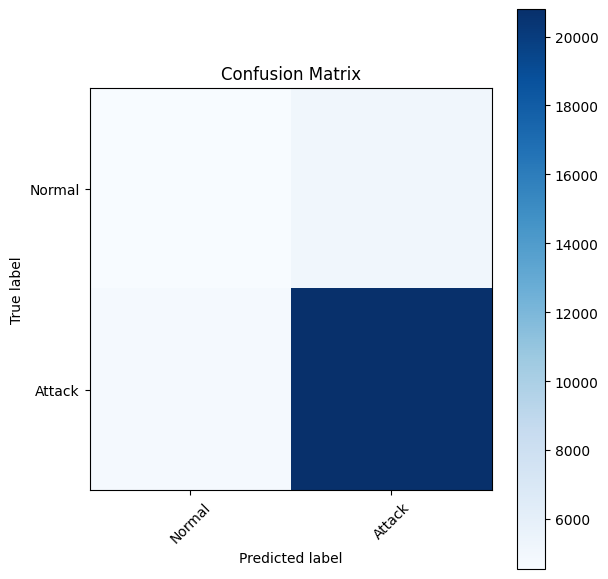

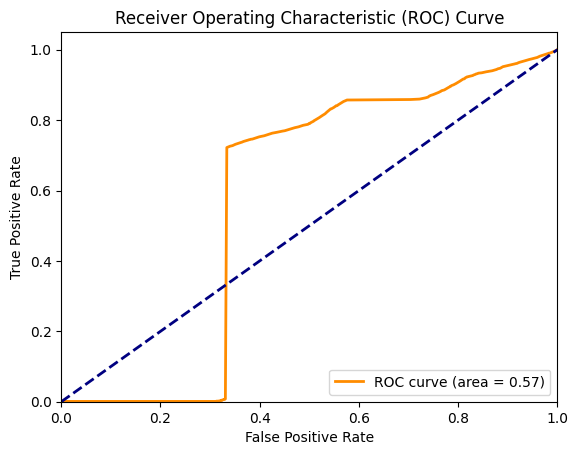

In [ ]:
# Evaluate an generate metrics using our `evaluate_model` function

report, cm, roc_auc = evaluate_model('best_model_generic.keras', X_test, y_test, class_names=['Normal', 'Attack'])

# Tyler Burguillos 10/06/2024

## Model 2 (ReLU FNN)

### Setting up Early Stopping and Model Checkpoints

This block defines callbacks for early stopping to prevent overfitting, and model checkpoints to save the best models during Hyperband and Bayesian optimization.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define early stopping to monitor validation loss and stop early if performance stagnates
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Define Model Checkpoints for Bayesian tuning to save the best model to a file
checkpoint_filepath = 'best_model_relu.keras'
model_checkpoint = ModelCheckpoint(checkpoint_filepath, monitor= 'val_loss', save_best_only=True, verbose=1)

# Tyler Burguillos 10/06/2024

### Defining the FNN Model Builder Function

This block contains the core of our tunable fnn model builder, allowing us to experiment with different numbers of units, dropout rate, activation functions, and optimizers. The defaults can be updated based on the results of the tuning.

In [ ]:
!pip install -q -U keras-tuner
import tensorflow as tf
import keras_tuner as kt

def fnn_model_builder_relu(hp):
  fnn_model = tf.keras.Sequential()

  # NOTE: After running these tuning models, we can update the "default" values for each metric to the best values found by our tuners for further testing by all teammates.
  # The average runtime of the hyperband tuner at max_epochs=20 and factor=3 is 30 trials @ 26m 12s
  # The average runtime of the bayesian tuner at max_trials=50 and executions_per_tria=1 is 50 trials @ 01h 55m 32s

  # Tune the number of units
  hp_units = hp.Int('units', min_value=32, max_value=512, step=32, default=448)
  fnn_model.add(tf.keras.layers.Dense(units=hp_units, activation='relu'))

  # Droput rate
  hp_dropout = hp.Float('dropout_rate', min_value=0.0, max_value=0.4, step=0.1, default=0.3)
  fnn_model.add(tf.keras.layers.Dropout(hp_dropout))

  # Add additional layers (if desired)
  hp_hidden_units = hp.Int('hidden_units', min_value=32, max_value=256, step=32, default=128)
  fnn_model.add(tf.keras.layers.Dense(units=hp_hidden_units, activation='relu'))

  fnn_model.add(tf.keras.layers.Dense(2, activation='softmax'))

# Tyler Burguillos 10/06/2024

# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------

  # Tune the optimizer type
  hp_optimizer = hp.Choice('optimizer', values=['adam', 'sgd'], default='adam')

  if hp_optimizer == 'adam':
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4], default=1e-3))
  else:
    optimizer = tf.keras.optimizers.SGD(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4], default=1e-3))

  fnn_model.compile(optimizer=optimizer,
                loss='categorical_crossentropy',
                metrics=['accuracy'])

  return fnn_model

# Nishan Maharjan 10/06/2024

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.1 MB/s eta 0:00:00


### Bayesian Optimization Tuning

Here we use Bayesian Optimization to refine our model search even further, focusing on finding the most accurate configuration over 50 trials.

In [ ]:
# Setup the Bayesian tuner
bayesian_tuner = kt.BayesianOptimization(
    fnn_model_builder_relu,
    objective='val_accuracy',
    max_trials=30,  # number of different hyperparameter combinations to try
    executions_per_trial=1,
    directory='bayesian_tuning',
    project_name='fnn_tuning_relu'
)

# Run the Bayesian search
bayesian_tuner.search(X_train, y_train, epochs=30, validation_data=(X_test, y_test),
                      callbacks=[early_stopping, model_checkpoint])

# Retrieve the best hyperparameters from Bayesian Optimization
best_hps_bayesian = bayesian_tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Bayesian Optimization found these optimal values: {best_hps_bayesian.values}")

# Austin Nolte 10/06/2024

Trial 30 Complete [00h 00m 33s]
val_accuracy: 0.8123827576637268

Best val_accuracy So Far: 0.8123827576637268
Total elapsed time: 00h 30m 11s
Bayesian Optimization found these optimal values: {'units': 160, 'dropout_rate': 0.30000000000000004, 'hidden_units': 96, 'optimizer': 'adam', 'learning_rate': 0.0001}


### Evaluating the FNN Best reLU Model

In these blocks, we load the best model from the Bayesian search and evaluate its performance on the test data to see how it performed

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Classificaition Report: 

              precision    recall  f1-score   support

      Normal       1.00      0.32      0.48      9624
      Attack       0.79      1.00      0.89     25554

    accuracy                           0.81     35178
   macro avg       0.90      0.66      0.68     35178
weighted avg       0.85      0.81      0.77     35178


 Confusion Matrix:
 [[ 3033  6591]
 [    9 25545]] 



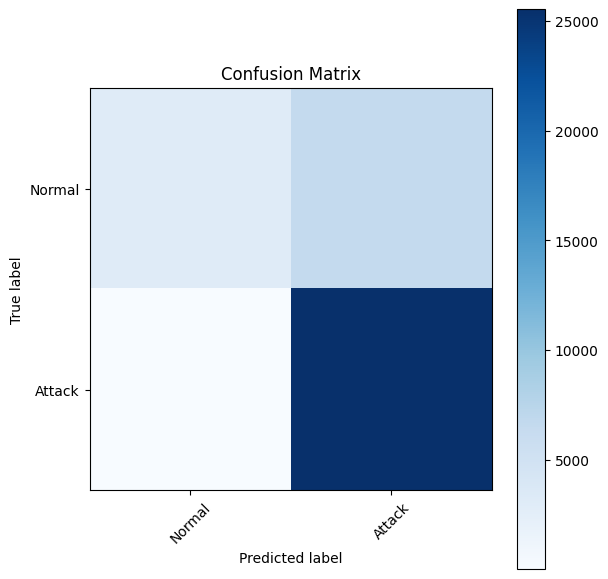

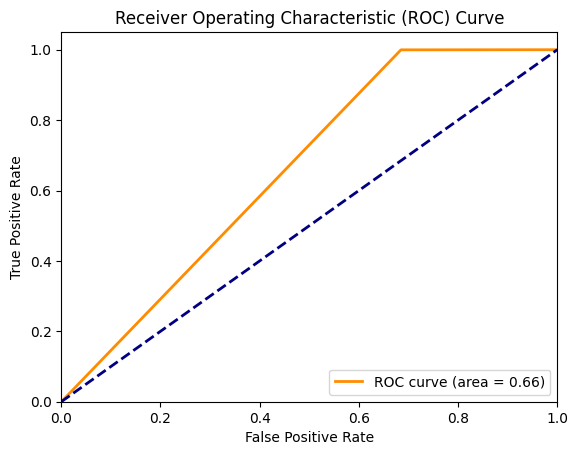

In [ ]:
# Evaluate an generate metrics using our `evaluate_model` function

report, cm, roc_auc = evaluate_model('best_model_relu.keras', X_test, y_test, class_names=['Normal', 'Attack'])

# Tyler Burguillos 10/06/2024

## Model 3 (Sigmoid FNN)

### Setting up Early Stopping and Model Checkpoints

This block defines callbacks for early stopping to prevent overfitting, and model checkpoints to save the best models during Hyperband and Bayesian optimization.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define early stopping to monitor validation loss and stop early if performance stagnates
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Define Model Checkpoints for Bayesian tuning to save the best model to a file
checkpoint_filepath = 'best_model_sigmoid.keras'
model_checkpoint = ModelCheckpoint(checkpoint_filepath, monitor= 'val_loss', save_best_only=True, verbose=1)

# Tyler Burguillos 10/06/2024

### Defining the FNN Model Builder Function

This block contains the core of our tunable fnn model builder, allowing us to experiment with different numbers of units, dropout rate, activation functions, and optimizers. The defaults can be updated based on the results of the tuning.

In [ ]:
!pip install -q -U keras-tuner
import tensorflow as tf
import keras_tuner as kt

def fnn_model_builder_sigmoid(hp):
  fnn_model = tf.keras.Sequential()

  # NOTE: After running these tuning models, we can update the "default" values for each metric to the best values found by our tuners for further testing by all teammates.
  # The average runtime of the hyperband tuner at max_epochs=20 and factor=3 is 30 trials @ 26m 12s
  # The average runtime of the bayesian tuner at max_trials=50 and executions_per_tria=1 is 50 trials @ 01h 55m 32s

  # Tune the number of units
  hp_units = hp.Int('units', min_value=32, max_value=512, step=32, default=448)
  fnn_model.add(tf.keras.layers.Dense(units=hp_units, activation='sigmoid'))

  # Droput rate
  hp_dropout = hp.Float('dropout_rate', min_value=0.0, max_value=0.4, step=0.1, default=0.3)
  fnn_model.add(tf.keras.layers.Dropout(hp_dropout))

  # Add additional layers (if desired)
  hp_hidden_units = hp.Int('hidden_units', min_value=32, max_value=256, step=32, default=128)
  fnn_model.add(tf.keras.layers.Dense(units=hp_hidden_units, activation='sigmoid'))

  fnn_model.add(tf.keras.layers.Dense(2, activation='softmax'))

# Tyler Burguillos 10/06/2024

# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------

  # Tune the optimizer type
  hp_optimizer = hp.Choice('optimizer', values=['adam', 'sgd'], default='adam')

  if hp_optimizer == 'adam':
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4], default=1e-3))
  else:
    optimizer = tf.keras.optimizers.SGD(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4], default=1e-3))

  fnn_model.compile(optimizer=optimizer,
                loss='categorical_crossentropy',
                metrics=['accuracy'])

  return fnn_model

# Nishan Maharjan 10/06/2024

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.4 MB/s eta 0:00:00


### Bayesian Optimization Tuning

Here we use Bayesian Optimization to refine our model search even further, focusing on finding the most accurate configuration over 50 trials.

In [ ]:
# Setup the Bayesian tuner
bayesian_tuner = kt.BayesianOptimization(
    fnn_model_builder_sigmoid,
    objective='val_accuracy',
    max_trials=30,  # number of different hyperparameter combinations to try
    executions_per_trial=1,
    directory='bayesian_tuning',
    project_name='fnn_tuning_sigmoid'
)

# Run the Bayesian search
bayesian_tuner.search(X_train, y_train, epochs=30, validation_data=(X_test, y_test),
                      callbacks=[early_stopping, model_checkpoint])

# Retrieve the best hyperparameters from Bayesian Optimization
best_hps_bayesian = bayesian_tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Bayesian Optimization found these optimal values: {best_hps_bayesian.values}")

# Austin Nolte 10/06/2024

Trial 30 Complete [00h 01m 09s]
val_accuracy: 0.7264199256896973

Best val_accuracy So Far: 0.8122121691703796
Total elapsed time: 00h 35m 30s
Bayesian Optimization found these optimal values: {'units': 32, 'dropout_rate': 0.4, 'hidden_units': 224, 'optimizer': 'adam', 'learning_rate': 0.0001}


### Evaluating the FNN Best Sigmoid Model

In these blocks, we load the best model from the Bayesian search and evaluate its performance on the test data to see how it performed

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m


Classificaition Report: 

              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00      9624
      Attack       0.73      1.00      0.84     25554

    accuracy                           0.73     35178
   macro avg       0.36      0.50      0.42     35178
weighted avg       0.53      0.73      0.61     35178


 Confusion Matrix:
 [[    0  9624]
 [    0 25554]] 



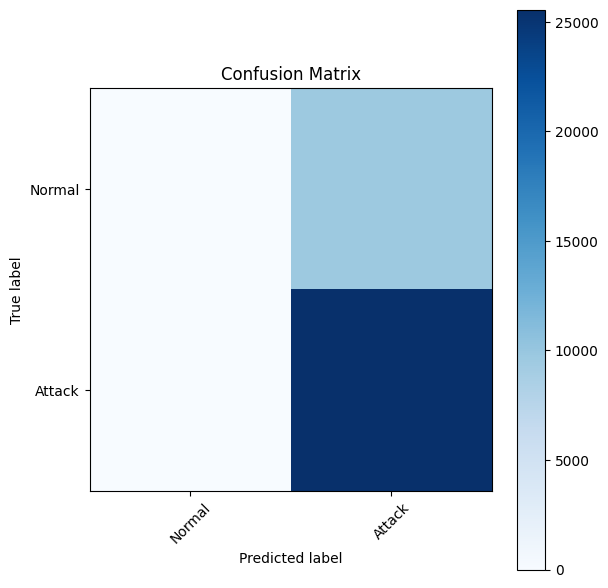

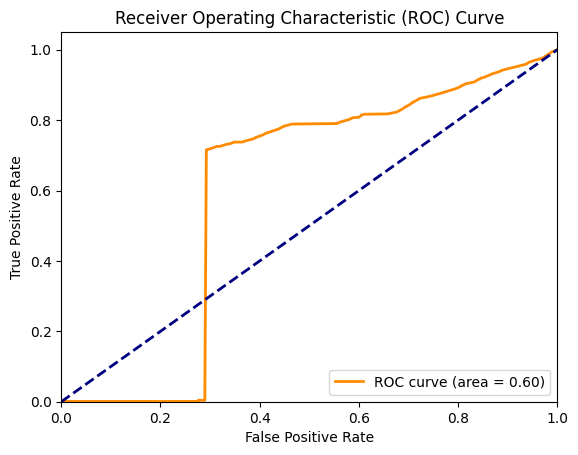

In [ ]:
# Evaluate an generate metrics using our `evaluate_model` function

report, cm, roc_auc = evaluate_model('best_model_sigmoid.keras', X_test, y_test, class_names=['Normal', 'Attack'])

# Tyler Burguillos 10/06/2024

## Model 4 (Tanh FNN)

### Setting up Early Stopping and Model Checkpoints

This block defines callbacks for early stopping to prevent overfitting, and model checkpoints to save the best models during Hyperband and Bayesian optimization.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define early stopping to monitor validation loss and stop early if performance stagnates
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Define Model Checkpoints for Bayesian tuning to save the best model to a file
checkpoint_filepath = 'best_model_tanh.keras'
model_checkpoint = ModelCheckpoint(checkpoint_filepath, monitor= 'val_loss', save_best_only=True, verbose=1)

# Tyler Burguillos 10/06/2024

### Defining the FNN Model Builder Function

This block contains the core of our tunable fnn model builder, allowing us to experiment with different numbers of units, dropout rate, activation functions, and optimizers. The defaults can be updated based on the results of the tuning.

In [ ]:
!pip install -q -U keras-tuner
import tensorflow as tf
import keras_tuner as kt

def fnn_model_builder_tanh(hp):
  fnn_model = tf.keras.Sequential()

  # NOTE: After running these tuning models, we can update the "default" values for each metric to the best values found by our tuners for further testing by all teammates.
  # The average runtime of the hyperband tuner at max_epochs=20 and factor=3 is 30 trials @ 26m 12s
  # The average runtime of the bayesian tuner at max_trials=50 and executions_per_tria=1 is 50 trials @ 01h 55m 32s

  # Tune the number of units
  hp_units = hp.Int('units', min_value=32, max_value=512, step=32, default=448)
  fnn_model.add(tf.keras.layers.Dense(units=hp_units, activation='tanh'))

  # Droput rate
  hp_dropout = hp.Float('dropout_rate', min_value=0.0, max_value=0.4, step=0.1, default=0.3)
  fnn_model.add(tf.keras.layers.Dropout(hp_dropout))

  # Add additional layers (if desired)
  hp_hidden_units = hp.Int('hidden_units', min_value=32, max_value=256, step=32, default=128)
  fnn_model.add(tf.keras.layers.Dense(units=hp_hidden_units, activation='tanh'))

  fnn_model.add(tf.keras.layers.Dense(2, activation='softmax'))

# Tyler Burguillos 10/06/2024

# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------

  # Tune the optimizer type
  hp_optimizer = hp.Choice('optimizer', values=['adam', 'sgd'], default='adam')

  if hp_optimizer == 'adam':
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4], default=1e-3))
  else:
    optimizer = tf.keras.optimizers.SGD(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4], default=1e-3))

  fnn_model.compile(optimizer=optimizer,
                loss='categorical_crossentropy',
                metrics=['accuracy'])

  return fnn_model

# Nishan Maharjan 10/06/2024

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.7 MB/s eta 0:00:00


### Bayesian Optimization Tuning

Here we use Bayesian Optimization to refine our model search even further, focusing on finding the most accurate configuration over 50 trials.

In [ ]:
# Setup the Bayesian tuner
bayesian_tuner = kt.BayesianOptimization(
    fnn_model_builder_tanh,
    objective='val_accuracy',
    max_trials=30,  # number of different hyperparameter combinations to try
    executions_per_trial=1,
    directory='bayesian_tuning',
    project_name='fnn_tuning_tanh'
)

# Run the Bayesian search
bayesian_tuner.search(X_train, y_train, epochs=30, validation_data=(X_test, y_test),
                      callbacks=[early_stopping, model_checkpoint])

# Retrieve the best hyperparameters from Bayesian Optimization
best_hps_bayesian = bayesian_tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Bayesian Optimization found these optimal values: {best_hps_bayesian.values}")

# Austin Nolte 10/06/2024

Trial 30 Complete [00h 00m 41s]
val_accuracy: 0.726732611656189

Best val_accuracy So Far: 0.812354326248169
Total elapsed time: 00h 59m 21s
Bayesian Optimization found these optimal values: {'units': 32, 'dropout_rate': 0.1, 'hidden_units': 96, 'optimizer': 'adam', 'learning_rate': 0.001}


### Evaluating the FNN Best Model

In these blocks, we load the best model from the Bayesian search and evaluate its performance on the test data to see how it performed

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Classificaition Report: 

              precision    recall  f1-score   support

      Normal       0.48      0.02      0.05      9624
      Attack       0.73      0.99      0.84     25554

    accuracy                           0.73     35178
   macro avg       0.61      0.51      0.44     35178
weighted avg       0.66      0.73      0.62     35178


 Confusion Matrix:
 [[  238  9386]
 [  253 25301]] 



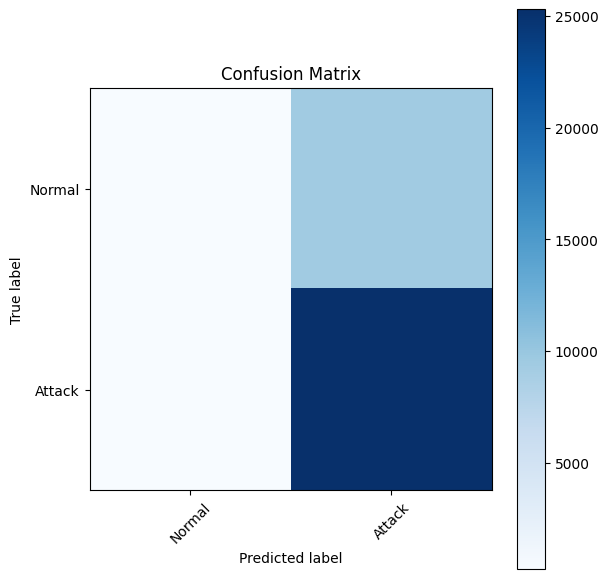

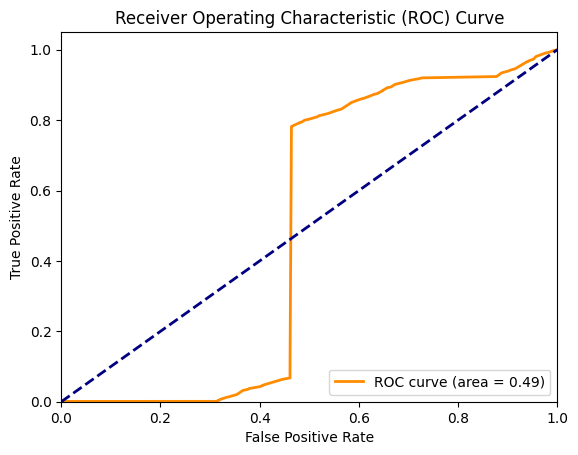

In [ ]:
# Evaluate an generate metrics using our `evaluate_model` function

report, cm, roc_auc = evaluate_model('best_model_tanh.keras', X_test, y_test, class_names=['Normal', 'Attack'])

# Tyler Burguillos 10/06/2024

## Model 5 (Best FNN + Additional Feature)

### Setting up Early Stopping and Model Checkpoints

This block defines callbacks for early stopping to prevent overfitting, and model checkpoints to save the best models during Hyperband and Bayesian optimization.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define early stopping to monitor validation loss and stop early if performance stagnates
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Define Model Checkpoints for Bayesian tuning to save the best model to a file
checkpoint_filepath = 'best_model.keras'
model_checkpoint = ModelCheckpoint(checkpoint_filepath, monitor= 'val_loss', save_best_only=True, verbose=1)

# Tyler Burguillos 10/06/2024

### Defining the FNN Model Builder Function

This block contains the core of our tunable fnn model builder, allowing us to experiment with different numbers of units, dropout rate, activation functions, and optimizers. The defaults can be updated based on the results of the tuning.

In [ ]:
!pip install -q -U keras-tuner
import tensorflow as tf
import keras_tuner as kt

def fnn_model_builder_best(hp):
  fnn_model = tf.keras.Sequential()

  # NOTE: After running these tuning models, we can update the "default" values for each metric to the best values found by our tuners for further testing by all teammates.
  # The average runtime of the hyperband tuner at max_epochs=20 and factor=3 is 30 trials @ 26m 12s
  # The average runtime of the bayesian tuner at max_trials=50 and executions_per_tria=1 is 50 trials @ 01h 55m 32s

  # Tune the number of units
  fnn_model.add(tf.keras.layers.Dense(units=160, activation='relu'))

  # Droput rate
  fnn_model.add(tf.keras.layers.Dropout(0.30000000000000004))

  # Add additional layers (if desired)
  fnn_model.add(tf.keras.layers.Dense(units=96, activation='relu'))

  fnn_model.add(tf.keras.layers.Dense(2, activation='softmax'))

# Tyler Burguillos 10/06/2024

# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------

  # Tune the optimizer type
  hp_optimizer = 'adam'

  if hp_optimizer == 'adam':
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
  else:
    optimizer = tf.keras.optimizers.SGD(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4], default=1e-3))

  fnn_model.compile(optimizer=optimizer,
                loss='categorical_crossentropy',
                metrics=['accuracy'])

  return fnn_model

# Nishan Maharjan 10/06/2024

### Bayesian Optimization Tuning

Here we use Bayesian Optimization to refine our model search even further, focusing on finding the most accurate configuration over 50 trials.

In [ ]:
# Setup the Bayesian tuner
bayesian_tuner = kt.BayesianOptimization(
    fnn_model_builder_best,
    objective='val_accuracy',
    max_trials=30,  # number of different hyperparameter combinations to try
    executions_per_trial=1,
    directory='bayesian_tuning',
    project_name='fnn_tuning_best'
)

# Run the Bayesian search
bayesian_tuner.search(X_train, y_train, epochs=60, validation_data=(X_test, y_test),
                      callbacks=[early_stopping, model_checkpoint])

# Retrieve the best hyperparameters from Bayesian Optimization
best_hps_bayesian = bayesian_tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Bayesian Optimization found these optimal values: {best_hps_bayesian.values}")

# Austin Nolte 10/06/2024

Trial 1 Complete [00h 01m 18s]
val_accuracy: 0.7264199256896973

Best val_accuracy So Far: 0.7264199256896973
Total elapsed time: 00h 01m 18s
Bayesian Optimization found these optimal values: {}


### Evaluating the FNN Best Overall Model

In these blocks, we load the best model from the Bayesian search and evaluate its performance on the test data to see how it performed

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Classificaition Report: 

              precision    recall  f1-score   support

      Normal       0.45      0.07      0.13      9624
      Attack       0.73      0.97      0.83     25554

    accuracy                           0.72     35178
   macro avg       0.59      0.52      0.48     35178
weighted avg       0.66      0.72      0.64     35178


 Confusion Matrix:
 [[  716  8908]
 [  884 24670]] 



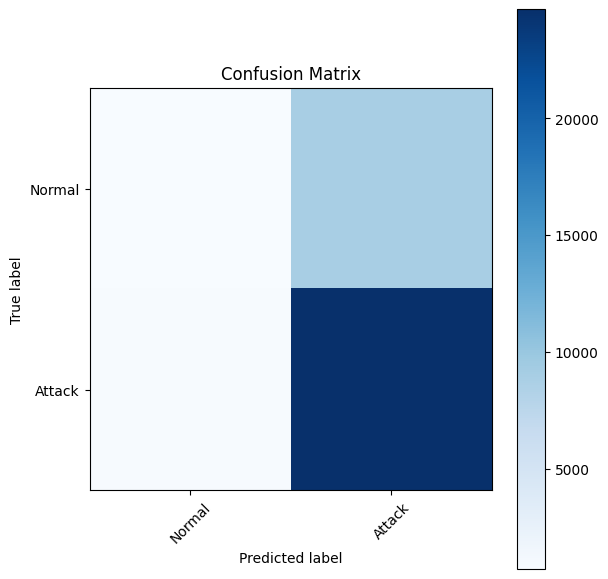

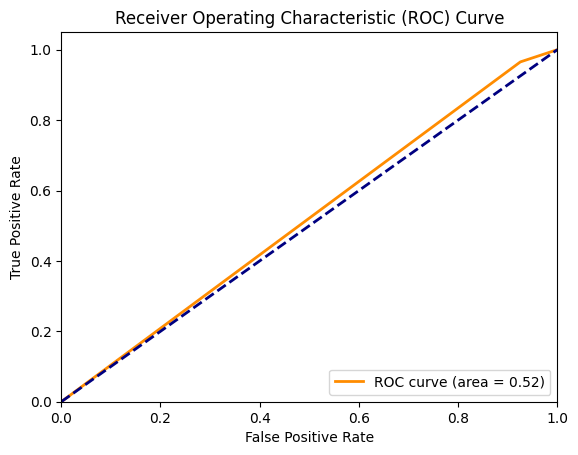

In [ ]:
# Evaluate an generate metrics using our `evaluate_model` function

report, cm, roc_auc = evaluate_model('best_model.keras', X_test, y_test, class_names=['Normal', 'Attack'])

# Tyler Burguillos 10/06/2024

### Additional Feature: Feature Importance and Class Weighting

In this section, we perform feature importance analysis using logistic regression to identify the top 10 most important features, and apply class weighting to handle the imbalance between the "Normal" and "Attack" classes.

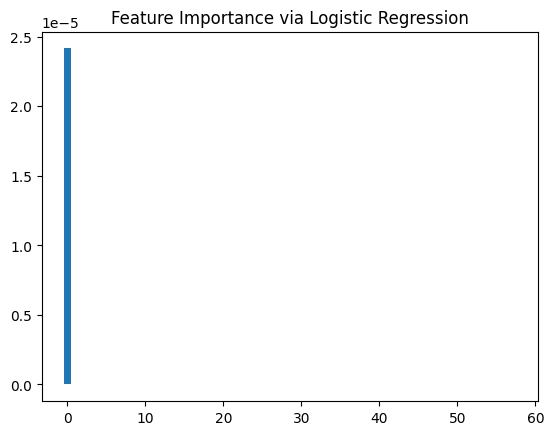

Shape of reduced X_train: (80595, 10)
Shape of reduced X_test: (35178, 10)


In [ ]:
# Perform feature importance analysis and dataset reduction
importance = feature_importance_analysis(X_train, y_train)

# Select top 10 features based on importance
top_features_idx = np.argsort(np.abs(importance))[-10:]
X_train_reduced = X_train[:, top_features_idx]
X_test_reduced = X_test[:, top_features_idx]

print(f"Shape of reduced X_train: {X_train_reduced.shape}")
print(f"Shape of reduced X_test: {X_test_reduced.shape}")

# Tyler Burguillos 10/06/2024

Epoch 1/50
2511/2519 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6960 - loss: 1142.6404
Epoch 1: val_loss did not improve from 64.39758
2519/2519 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.6961 - loss: 1140.2167 - val_accuracy: 0.7264 - val_loss: 391.5990
Epoch 2/50
2513/2519 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7316 - loss: 129.0167
Epoch 2: val_loss did not improve from 64.39758
2519/2519 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.7316 - loss: 128.9291 - val_accuracy: 0.7264 - val_loss: 173.1882
Epoch 3/50
2519/2519 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7368 - loss: 34.4119
Epoch 3: val_loss did not improve from 64.39758
2519/2519 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7368 - loss: 34.4081 - val_accuracy: 0.7264 - val_loss: 112.0566
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m


Classificaition Report: 

              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00      9624
      Attack       0.73      1.00      0.84     25554

    accuracy                           0.73     35178
   macro avg       0.36      0.50      0.42     35178
weighted avg       0.53      0.73      0.61     35178


 Confusion Matrix:
 [[    0  9624]
 [    0 25554]] 



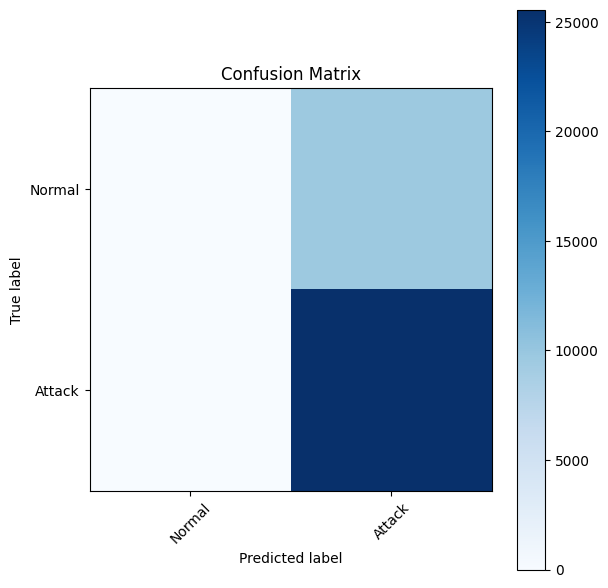

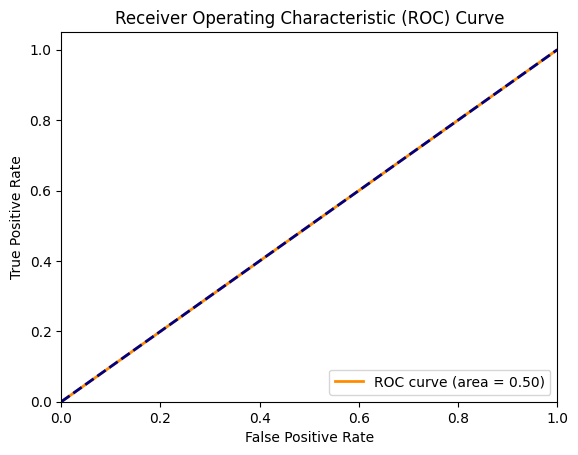

In [ ]:
# After obtaining the best hyperparameters, build the model using them
best_model = bayesian_tuner.hypermodel.build(best_hps_bayesian)

# Train the model for 50 epochs with the reduced dataset
history = best_model.fit(
    X_train_reduced, y_train,
    epochs=50,
    validation_data=(X_test_reduced, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Evaluate the model using the evaluation function
report, cm, roc_auc = evaluate_model('best_model.keras', X_test_reduced, y_test, class_names=['Normal', 'Attack'])

# Austin Nolte 10/06/2024

## Model 6 (Generic CNN):

### Setting up Early Stopping and Model Checkpoints

Reuse the early stopping and checkpoint logic from FNN but customise callbacks based on the CNN performance.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Defining early stopping and model checkpoint
early_stopping_cnn = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_checkpoint_cnn = ModelCheckpoint(filepath='best_cnn_model_generic.keras', monitor= 'val_loss', save_best_only=True, verbose=1)

# Austin Nolte 10/07/2024

### Defining the CNN Model Builder Function

Build a CNN model architecture with convolutional layers, pooling layers, and fully connected layers.

Specify hyperparameters for CNN layers such as:

- Number of filters.
- Kernel size.
- Pooling size.
- Activation functions.
- Dropout layers.

In [ ]:
!pip install -q -U keras-tuner
import tensorflow as tf
import keras_tuner as kt

def cnn_model_buidler_generic(hp):

  cnn = tf.keras.Sequential()

  # Tuning number of filters in conv2d layer
  hp_conv2d_units = hp.Int('units',min_value=16,max_value=512,step=16)

  cnn.add(tf.keras.layers.Conv2D(filters=hp_conv2d_units,kernel_size=(3,1),strides=(1,1),
                                 activation=hp.Choice('activation', values=['relu', 'sigmoid', 'tanh'], default='relu'),padding='same',input_shape=(58,1,1)))

  # Tune pooliing size manually! It causes crashing when using keras to do it automatically
  cnn.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 1), strides=(2, 1)))

  # Dropout rate
  hp_dropout = hp.Float('dropout_rate',min_value=0.0,max_value=0.5,step=0.05,default=0.0)
  cnn.add(tf.keras.layers.Dropout(hp_dropout))

  # Flatten before getting to dense layers
  cnn.add(tf.keras.layers.Flatten())

  # Tuning numbers of units
  hp_units = hp.Int('units', min_value=32, max_value=512,step=32)
  cnn.add(tf.keras.layers.Dense(units=hp_units,activation='relu'))

  # For adding additional layers
  hp_hidden_layers = hp.Int('hidden_units',min_value=32,max_value=256,step=32,default=32)
  cnn.add(tf.keras.layers.Dense(units=hp_hidden_layers, activation=hp.Choice('activation', values=['relu', 'sigmoid', 'tanh'], default='relu')))

  # Output Layer
  cnn.add(tf.keras.layers.Dense(2, activation='softmax'))

  # Tune the optimizer type
  hp_optimizer = hp.Choice('optimizer', values=['adam', 'sgd'], default='adam')

  hp_learning_rate = hp.Choice('learning_rate',values=[1e-2,1e-3,1e-4])

  if hp_optimizer == 'adam':
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)
  else:
    optimizer = tf.keras.optimizers.SGD(learning_rate=hp_learning_rate)

  cnn.compile(optimizer=optimizer,loss=tf.keras.losses.categorical_crossentropy,metrics=['accuracy'])

  return cnn

# Austin Nolte 10/07/24

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.4 MB/s eta 0:00:00


### Bayesian Optimization Tuning

Adapt the Bayesian optimization setup to handle CNN-specific hyperparameters, such as:

- Number of filters (for convolutional layers).
- Kernel size (for convolutional layers).
- Pooling size (for pooling layers).
- Dropout rate (for regulaization).

In [ ]:
# Making Bayesian tuner

tuner = kt.BayesianOptimization(
    cnn_model_buidler_generic,
    objective='val_accuracy',
    max_trials=30, # 5 for testing, 30 for normal
    executions_per_trial=1,
    directory='bayesian_tuning_cnn',
    project_name='cnn_tuning_generic'
)

tuner.search(X_train_cnn,y_train,epochs=30,validation_data=(X_test_cnn,y_test),callbacks=[early_stopping_cnn,model_checkpoint_cnn])

# Retrieve the best hyperparameters from Bayesian Optimization for cnn model
best_cnn_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Bayesian Optimization found these optimal values: {best_cnn_hyperparameters.values}")

# Austin Nolte 10/07/24

Trial 30 Complete [00h 00m 38s]
val_accuracy: 0.7475126385688782

Best val_accuracy So Far: 0.7700267434120178
Total elapsed time: 00h 34m 37s
Bayesian Optimization found these optimal values: {'units': 224, 'activation': 'tanh', 'dropout_rate': 0.30000000000000004, 'hidden_units': 224, 'optimizer': 'sgd', 'learning_rate': 0.0001}


### Evaluating the Best CNN Model

Run classification and performance evaluation metrics (like precision, recall, F1-score, etc.) on the best model from Bayesian optimization.

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

Classificaition Report: 

              precision    recall  f1-score   support

      Normal       0.61      0.21      0.32      9624
      Attack       0.76      0.95      0.85     25554

    accuracy                           0.75     35178
   macro avg       0.69      0.58      0.58     35178
weighted avg       0.72      0.75      0.70     35178


 Confusion Matrix:
 [[ 2067  7557]
 [ 1325 24229]] 



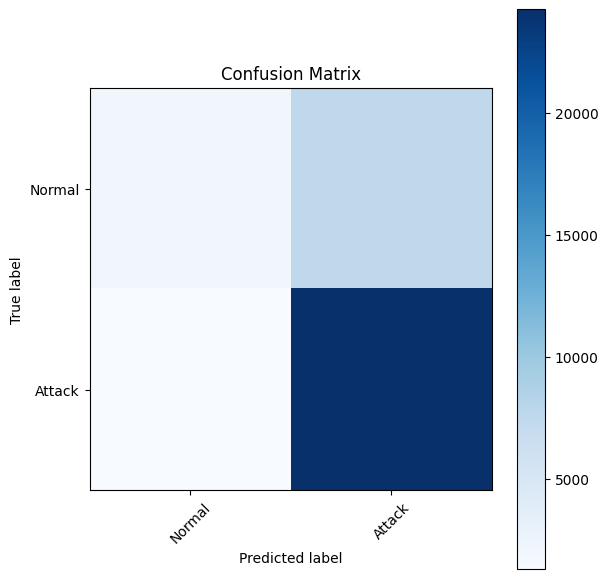

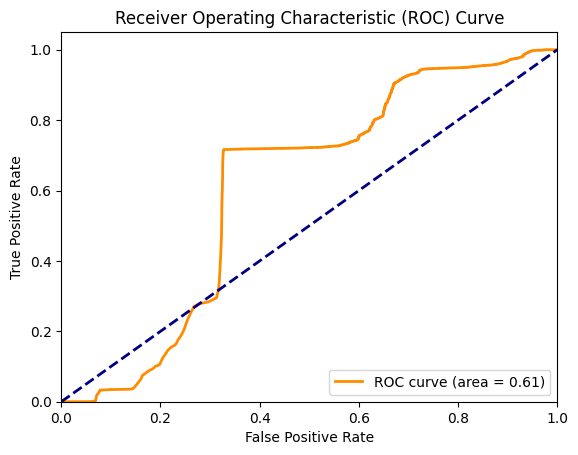

In [ ]:
# Evaluate an generate metrics using our `evaluate_model` function

report, cm, roc_auc = evaluate_model('best_cnn_model_generic.keras', X_test_cnn, y_test, class_names=['Normal', 'Attack'])

# Austin Nolte: 10/07/2024

## Model 7 (CNN relu):

### Setting up Early Stopping and Model Checkpoints

Reuse the early stopping and checkpoint logic from FNN but customise callbacks based on the CNN performance.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Defining early stopping and model checkpoint
early_stopping_cnn = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_checkpoint_cnn = ModelCheckpoint(filepath='best_cnn_model_relu.keras', monitor= 'val_loss', save_best_only=True, verbose=1)

# Austin Nolte 10/07/2024

### Defining the CNN Model Builder Function

Build a CNN model architecture with convolutional layers, pooling layers, and fully connected layers.

Specify hyperparameters for CNN layers such as:

- Number of filters.
- Kernel size.
- Pooling size.
- Activation functions.
- Dropout layers.

In [ ]:
!pip install -q -U keras-tuner
import tensorflow as tf
import keras_tuner as kt

def cnn_model_buidler_relu(hp):

  cnn = tf.keras.Sequential()

  # Tuning number of filters in conv2d layer
  hp_conv2d_units = hp.Int('units',min_value=16,max_value=512,step=16)

  cnn.add(tf.keras.layers.Conv2D(filters=hp_conv2d_units,kernel_size=(3,1),strides=(1,1),
                                 activation='relu',padding='same',input_shape=(58,1,1)))

  # Tune pooliing size manually! It causes crashing when using keras to do it automatically
  cnn.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 1), strides=(2, 1)))

  # Dropout rate
  hp_dropout = hp.Float('dropout_rate',min_value=0.0,max_value=0.5,step=0.05,default=0.0)
  cnn.add(tf.keras.layers.Dropout(hp_dropout))

  # Flatten before getting to dense layers
  cnn.add(tf.keras.layers.Flatten())

  # Tuning numbers of units
  hp_units = hp.Int('units', min_value=32, max_value=512,step=32)
  cnn.add(tf.keras.layers.Dense(units=hp_units,activation='relu'))

  # For adding additional layers
  hp_hidden_layers = hp.Int('hidden_units',min_value=32,max_value=256,step=32,default=32)
  cnn.add(tf.keras.layers.Dense(units=hp_hidden_layers, activation=hp.Choice('activation', values=['relu', 'sigmoid', 'tanh'], default='relu')))

  # Output Layer
  cnn.add(tf.keras.layers.Dense(2, activation='softmax'))

  # Tune the optimizer type
  hp_optimizer = hp.Choice('optimizer', values=['adam', 'sgd'], default='adam')

  hp_learning_rate = hp.Choice('learning_rate',values=[1e-2,1e-3,1e-4])

  if hp_optimizer == 'adam':
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)
  else:
    optimizer = tf.keras.optimizers.SGD(learning_rate=hp_learning_rate)

  cnn.compile(optimizer=optimizer,loss=tf.keras.losses.categorical_crossentropy,metrics=['accuracy'])

  return cnn

# Austin Nolte 10/07/24

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.6 MB/s eta 0:00:00


### Bayesian Optimization Tuning

Adapt the Bayesian optimization setup to handle CNN-specific hyperparameters, such as:

- Number of filters (for convolutional layers).
- Kernel size (for convolutional layers).
- Pooling size (for pooling layers).
- Dropout rate (for regulaization).

In [ ]:
# Making Bayesian tuner

tuner = kt.BayesianOptimization(
    cnn_model_buidler_relu,
    objective='val_accuracy',
    max_trials=30, # 5 for testing, 30 for normal
    executions_per_trial=1,
    directory='bayesian_tuning_cnn',
    project_name='cnn_tuning_relu'
)

tuner.search(X_train_cnn,y_train,epochs=30,validation_data=(X_test_cnn,y_test),callbacks=[early_stopping_cnn,model_checkpoint_cnn])

# Retrieve the best hyperparameters from Bayesian Optimization for cnn model
best_cnn_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Bayesian Optimization found these optimal values: {best_cnn_hyperparameters.values}")

# Austin Nolte 10/07/24

Trial 30 Complete [00h 00m 56s]
val_accuracy: 0.7264199256896973

Best val_accuracy So Far: 0.8122406005859375
Total elapsed time: 00h 40m 31s
Bayesian Optimization found these optimal values: {'units': 464, 'dropout_rate': 0.15000000000000002, 'hidden_units': 256, 'activation': 'sigmoid', 'optimizer': 'sgd', 'learning_rate': 0.001}


### Evaluating the Best CNN Model

Run classification and performance evaluation metrics (like precision, recall, F1-score, etc.) on the best model from Bayesian optimization.

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m


Classificaition Report: 

              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00      9624
      Attack       0.73      1.00      0.84     25554

    accuracy                           0.73     35178
   macro avg       0.36      0.50      0.42     35178
weighted avg       0.53      0.73      0.61     35178


 Confusion Matrix:
 [[    0  9624]
 [    0 25554]] 



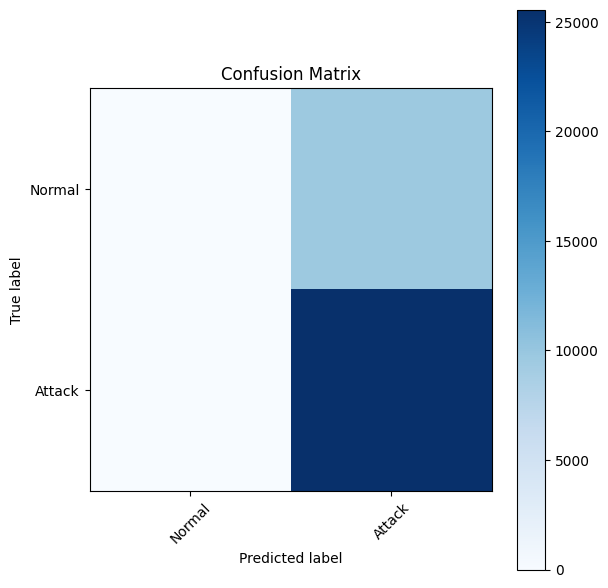

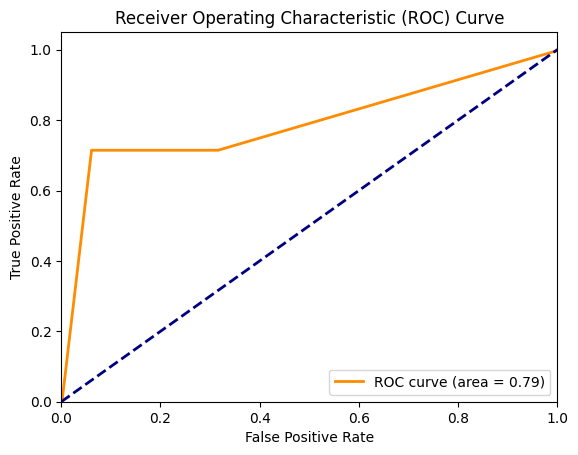

In [ ]:
# Evaluate an generate metrics using our `evaluate_model` function

report, cm, roc_auc = evaluate_model('best_cnn_model_relu.keras', X_test_cnn, y_test, class_names=['Normal', 'Attack'])

# Austin Nolte: 10/07/2024

## Model 8 (CNN tanh):

### Setting up Early Stopping and Model Checkpoints

Reuse the early stopping and checkpoint logic from FNN but customise callbacks based on the CNN performance.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Defining early stopping and model checkpoint
early_stopping_cnn = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_checkpoint_cnn = ModelCheckpoint(filepath='best_cnn_model_tanh.keras', monitor= 'val_loss', save_best_only=True, verbose=1)

# Austin Nolte 10/07/2024

### Defining the CNN Model Builder Function

Build a CNN model architecture with convolutional layers, pooling layers, and fully connected layers.

Specify hyperparameters for CNN layers such as:

- Number of filters.
- Kernel size.
- Pooling size.
- Activation functions.
- Dropout layers.

In [ ]:
!pip install -q -U keras-tuner
import tensorflow as tf
import keras_tuner as kt
def cnn_model_buidler_tanh(hp):

  cnn = tf.keras.Sequential()

  # Tuning number of filters in conv2d layer
  hp_conv2d_units = hp.Int('units',min_value=16,max_value=512,step=16)

  cnn.add(tf.keras.layers.Conv2D(filters=hp_conv2d_units,kernel_size=(3,1),strides=(1,1),
                                 activation='relu',padding='same',input_shape=(58,1,1)))

  # Tune pooliing size manually! It causes crashing when using keras to do it automatically
  cnn.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 1), strides=(2, 1)))

  # Dropout rate
  hp_dropout = hp.Float('dropout_rate',min_value=0.0,max_value=0.5,step=0.05,default=0.0)
  cnn.add(tf.keras.layers.Dropout(hp_dropout))

  # Flatten before getting to dense layers
  cnn.add(tf.keras.layers.Flatten())

  # Tuning numbers of units
  hp_units = hp.Int('units', min_value=32, max_value=512,step=32)
  cnn.add(tf.keras.layers.Dense(units=hp_units,activation='relu'))

  # For adding additional layers
  hp_hidden_layers = hp.Int('hidden_units',min_value=32,max_value=256,step=32,default=32)
  cnn.add(tf.keras.layers.Dense(units=hp_hidden_layers, activation=hp.Choice('activation', values=['relu', 'sigmoid', 'tanh'], default='relu')))

  # Output Layer
  cnn.add(tf.keras.layers.Dense(2, activation='softmax'))

  # Tune the optimizer type
  hp_optimizer = hp.Choice('optimizer', values=['adam', 'sgd'], default='adam')

  hp_learning_rate = hp.Choice('learning_rate',values=[1e-2,1e-3,1e-4])

  if hp_optimizer == 'adam':
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)
  else:
    optimizer = tf.keras.optimizers.SGD(learning_rate=hp_learning_rate)

  cnn.compile(optimizer=optimizer,loss=tf.keras.losses.categorical_crossentropy,metrics=['accuracy'])

  return cnn

# Austin Nolte 10/07/24

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.1 MB/s eta 0:00:00


### Bayesian Optimization Tuning

Adapt the Bayesian optimization setup to handle CNN-specific hyperparameters, such as:

- Number of filters (for convolutional layers).
- Kernel size (for convolutional layers).
- Pooling size (for pooling layers).
- Dropout rate (for regulaization).

In [ ]:
# Making Bayesian tuner

tuner = kt.BayesianOptimization(
    cnn_model_buidler_tanh,
    objective='val_accuracy',
    max_trials=30, # 5 for testing, 30 for normal
    executions_per_trial=1,
    directory='bayesian_tuning_cnn',
    project_name='cnn_tuning_tanh'
)

tuner.search(X_train_cnn,y_train,epochs=30,validation_data=(X_test_cnn,y_test),callbacks=[early_stopping_cnn,model_checkpoint_cnn])

# Retrieve the best hyperparameters from Bayesian Optimization for cnn model
best_cnn_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Bayesian Optimization found these optimal values: {best_cnn_hyperparameters.values}")

# Austin Nolte 10/07/24

Trial 30 Complete [00h 00m 59s]
val_accuracy: 0.7264199256896973

Best val_accuracy So Far: 0.726476788520813
Total elapsed time: 00h 38m 20s
Bayesian Optimization found these optimal values: {'units': 304, 'dropout_rate': 0.30000000000000004, 'hidden_units': 224, 'activation': 'sigmoid', 'optimizer': 'sgd', 'learning_rate': 0.01}


### Evaluating the Best CNN Model

Run classification and performance evaluation metrics (like precision, recall, F1-score, etc.) on the best model from Bayesian optimization.

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

Classificaition Report: 

              precision    recall  f1-score   support

      Normal       0.48      0.68      0.56      9624
      Attack       0.86      0.72      0.78     25554

    accuracy                           0.71     35178
   macro avg       0.67      0.70      0.67     35178
weighted avg       0.75      0.71      0.72     35178


 Confusion Matrix:
 [[ 6552  3072]
 [ 7208 18346]] 



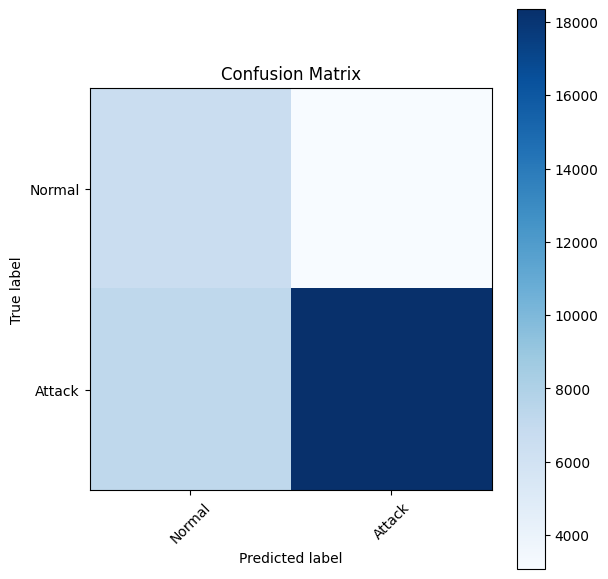

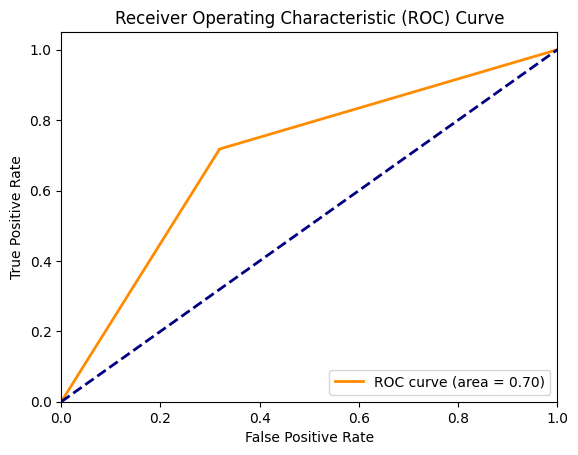

In [ ]:
# Evaluate an generate metrics using our `evaluate_model` function

report, cm, roc_auc = evaluate_model('best_cnn_model_tanh.keras', X_test_cnn, y_test, class_names=['Normal', 'Attack'])

# Austin Nolte: 10/07/2024

## Model 9 (CNN sigmoid):

### Setting up Early Stopping and Model Checkpoints

Reuse the early stopping and checkpoint logic from FNN but customise callbacks based on the CNN performance.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Defining early stopping and model checkpoint
early_stopping_cnn = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_checkpoint_cnn = ModelCheckpoint(filepath='best_cnn_model_sigmoid.keras', monitor= 'val_loss', save_best_only=True, verbose=1)

# Austin Nolte 10/07/2024

### Defining the CNN Model Builder Function

Build a CNN model architecture with convolutional layers, pooling layers, and fully connected layers.

Specify hyperparameters for CNN layers such as:

- Number of filters.
- Kernel size.
- Pooling size.
- Activation functions.
- Dropout layers.

In [ ]:
!pip install -q -U keras-tuner
import tensorflow as tf
import keras_tuner as kt

def cnn_model_buidler_sigmoid(hp):

  cnn = tf.keras.Sequential()

  # Tuning number of filters in conv2d layer
  hp_conv2d_units = hp.Int('units',min_value=16,max_value=512,step=16)

  cnn.add(tf.keras.layers.Conv2D(filters=hp_conv2d_units,kernel_size=(3,1),strides=(1,1),
                                 activation='relu',padding='same',input_shape=(58,1,1)))

  # Tune pooliing size manually! It causes crashing when using keras to do it automatically
  cnn.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 1), strides=(2, 1)))

  # Dropout rate
  hp_dropout = hp.Float('dropout_rate',min_value=0.0,max_value=0.5,step=0.05,default=0.0)
  cnn.add(tf.keras.layers.Dropout(hp_dropout))

  # Flatten before getting to dense layers
  cnn.add(tf.keras.layers.Flatten())

  # Tuning numbers of units
  hp_units = hp.Int('units', min_value=32, max_value=512,step=32)
  cnn.add(tf.keras.layers.Dense(units=hp_units,activation='relu'))

  # For adding additional layers
  hp_hidden_layers = hp.Int('hidden_units',min_value=32,max_value=256,step=32,default=32)
  cnn.add(tf.keras.layers.Dense(units=hp_hidden_layers, activation=hp.Choice('activation', values=['relu', 'sigmoid', 'tanh'], default='relu')))

  # Output Layer
  cnn.add(tf.keras.layers.Dense(2, activation='softmax'))

  # Tune the optimizer type
  hp_optimizer = hp.Choice('optimizer', values=['adam', 'sgd'], default='adam')

  hp_learning_rate = hp.Choice('learning_rate',values=[1e-2,1e-3,1e-4])

  if hp_optimizer == 'adam':
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)
  else:
    optimizer = tf.keras.optimizers.SGD(learning_rate=hp_learning_rate)

  cnn.compile(optimizer=optimizer,loss=tf.keras.losses.categorical_crossentropy,metrics=['accuracy'])

  return cnn

# Austin Nolte 10/07/24

### Bayesian Optimization Tuning

Adapt the Bayesian optimization setup to handle CNN-specific hyperparameters, such as:

- Number of filters (for convolutional layers).
- Kernel size (for convolutional layers).
- Pooling size (for pooling layers).
- Dropout rate (for regulaization).

In [ ]:
# Making Bayesian tuner

tuner = kt.BayesianOptimization(
    cnn_model_buidler_sigmoid,
    objective='val_accuracy',
    max_trials=30, # 5 for testing, 30 for normal
    executions_per_trial=1,
    directory='bayesian_tuning_cnn',
    project_name='cnn_tuning_sigmoid'
)

tuner.search(X_train_cnn,y_train,epochs=30,validation_data=(X_test_cnn,y_test),callbacks=[early_stopping_cnn,model_checkpoint_cnn])

# Retrieve the best hyperparameters from Bayesian Optimization for cnn model
best_cnn_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Bayesian Optimization found these optimal values: {best_cnn_hyperparameters.values}")

# Austin Nolte 10/07/24

Trial 30 Complete [00h 00m 40s]
val_accuracy: 0.7264199256896973

Best val_accuracy So Far: 0.7264483571052551
Total elapsed time: 00h 32m 19s
Bayesian Optimization found these optimal values: {'units': 496, 'dropout_rate': 0.05, 'hidden_units': 224, 'activation': 'tanh', 'optimizer': 'sgd', 'learning_rate': 0.01}


### Evaluating the Best CNN Model

Run classification and performance evaluation metrics (like precision, recall, F1-score, etc.) on the best model from Bayesian optimization.

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

Classificaition Report: 

              precision    recall  f1-score   support

      Normal       0.27      1.00      0.43      9624
      Attack       0.92      0.00      0.00     25554

    accuracy                           0.27     35178
   macro avg       0.60      0.50      0.22     35178
weighted avg       0.75      0.27      0.12     35178


 Confusion Matrix:
 [[ 9623     1]
 [25542    12]] 



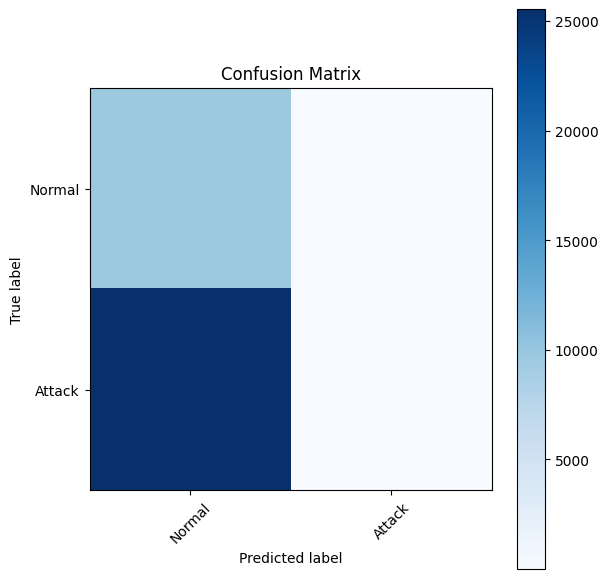

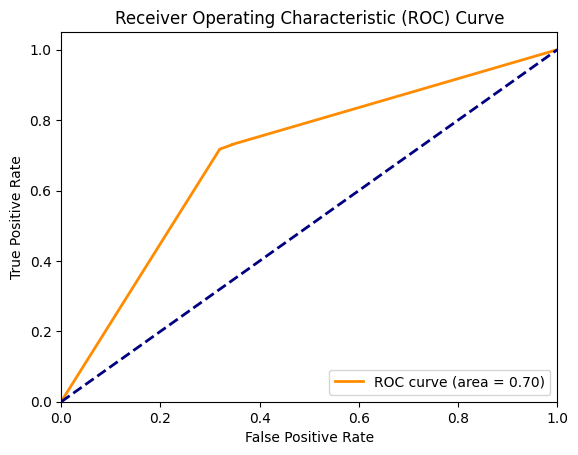

In [ ]:
# Evaluate an generate metrics using our `evaluate_model` function

report, cm, roc_auc = evaluate_model('best_cnn_model_sigmoid.keras', X_test_cnn, y_test, class_names=['Normal', 'Attack'])

# Austin Nolte: 10/07/2024

| Model  | Best Validation Accuracy | Hyperparameters |
|-|-|-|
| FNN (Generic)        | 0.8073                   | 64 units, tanh activation, 0.3 dropout, 160 hidden units, Adam optimizer, 0.001 learning rate |
| FNN (ReLU)           | 0.8123                   | 160 units, relu activation, 0.3 dropout, 96 hidden units, Adam optimizer, 0.0001 learning rate |
| FNN (Sigmoid)        | 0.8122                   | 32 units, sigmoid activation, 0.4 dropout, 224 hidden units, Adam optimizer, 0.0001 learning rate |
| **FNN (Tanh)**       | **0.8124**               | 32 units, tanh activation, 0.1 dropout, 96 hidden units, Adam optimizer, 0.001 learning rate |
| FNN Best + Feature   | ~0.812                   | Similar results with feature selection and fine-tuning        |
| CNN (Generic)        | 0.7700                   | 224 filters, tanh activation, 0.3 dropout, 224 hidden units, SGD optimizer, 0.0001 learning rate |
| CNN (ReLU)           | 0.8122                   | 464 filters, sigmoid activation, 0.15 dropout, 256 hidden units, SGD optimizer, 0.001 learning rate |
| CNN (Tanh)           | 0.7264                   | 304 filters, sigmoid activation, 0.3 dropout, 224 hidden units, SGD optimizer, 0.01 learning rate |
| CNN (Sigmoid)        | 0.7264                   | 496 filters, tanh activation, 0.05 dropout, 224 hidden units, SGD optimizer, 0.01 learning rate |


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
2519/2519 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.7563 - loss: 0.5620 - val_accuracy: 0.7264 - val_loss: 0.6775
Epoch 2/50
2519/2519 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7594 - loss: 0.5557 - val_accuracy: 0.2947 - val_loss: 0.7586
Epoch 3/50
2519/2519 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7583 - loss: 0.5553 - val_accuracy: 0.2740 - val_loss: 0.7854
Epoch 4/50
2519/2519 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7601 - loss: 0.5528 - val_accuracy: 0.2814 - val_loss: 0.8802
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8600 - loss: 0.5877
Test Accuracy: 0.7264
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m


Classificaition Report: 

              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00      9624
      Attack       0.73      1.00      0.84     25554

    accuracy                           0.73     35178
   macro avg       0.36      0.50      0.42     35178
weighted avg       0.53      0.73      0.61     35178


 Confusion Matrix:
 [[    0  9624]
 [    0 25554]] 



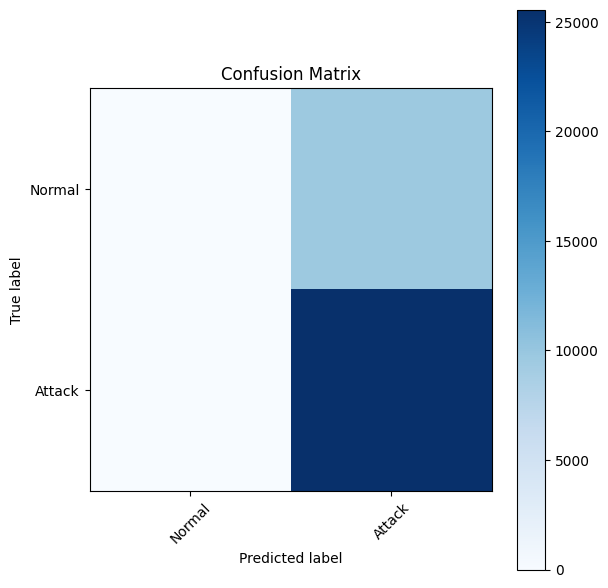

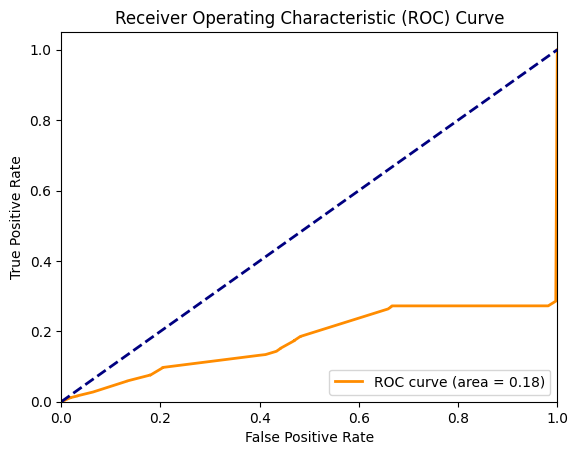

0.17801144062374133

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define the FNN (Tanh) model
def fnn_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation='tanh', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(96, activation='tanh'),
        tf.keras.layers.Dense(2, activation='softmax')
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Set up early stopping and model checkpoint callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_fnn_tanh_model.keras', monitor='val_loss', save_best_only=True)

# Train the model
model = fnn_model()
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load the best model and evaluate
best_model = tf.keras.models.load_model('best_fnn_tanh_model.keras')
loss, accuracy = best_model.evaluate(X_test, y_test, verbose=1)
print(f'Test Accuracy: {accuracy:.4f}')

# Generate evaluation metrics
y_pred, y_pred_classes = load_and_predict('best_fnn_tanh_model.keras', X_test)
report = generate_classification_report(y_test.argmax(axis=1), y_pred_classes, target_names=['Normal', 'Attack'])
plot_confusion_matrix(y_test.argmax(axis=1), y_pred_classes, ['Normal', 'Attack'])
plot_roc_curve(y_test.argmax(axis=1), y_pred)

# Tyler Burguillos 10/08/2024

#### Bayesian Optimization Experimentation Results:

List out the top-performing experiments similar to the FNN layout, but specific to CNN configurations (number of filters, kernel sizes,  etc.)

#### Bayesian Optimization Experimentation Results:

Please input your experimentation results here in the following format so we can narrow down our best model over multiple runs:

| **Experiment** | **Run by** | **Best val_accuracy** | **Units** | **Activation** | **Dropout Rate** | **Hidden Units** | **Optimizer** | **Learning Rate** | **Max Trials** | Executions Per Trial |
|-|-|-|-|-|-|-|-|-|-|-|
| 0 | Tyler | 0.8057734966278076 | 32 | tanh | 0.2 | 32 | sgd | 0.001 | 50 | 2 |
| CNN_relu | Austin Nolte | 0.7803 | 496 | tanh | 0.15 | 32 | sgd | 0.01 | 50 |1 |
| CNN_sigmoid | Austin Nolte | 0.8057734966278076 | 32 | tanh | 0.2 | 32 | sgd | 0.001 | 50 | 2 |
| CNN_tanh | Austin Nolte | 0.8057734966278076 | 32 | tanh | 0.2 | 32 | sgd | 0.001 | 50 | 2 |
| FNN_relu | Alan Lei | 0.7264199256896973 | 384 | relu | 0.4 | 256 | sgd | 0.001 | 30 | 1 |
| FNN_sigmoid | Alan Lei | 0.7264199256896973 | 288 | sigmoid | 0.0 | 192 | sgd | 0.0001 | 30 | 1 |
| FNN_tanh | Alan Lei | 0.8121837377548218 | 160 | tanh | 0.4 | 160 | adam | 0.01 | 30 | 1 |

#### Confusion Matrix Results per Experiment:

Keep track of confusion matrix results accross different experiments, indicating how well the CNN distinguishes between classes.

#### Confusion Matrix Results:

| **Exp** | **Run by** | **TN** | **FP** | **FN** | **TA** | **Total Normal** | **Total Attack** |
|-|-|-|-|-|-|-|-|
| 0 | Tyler | 845 | 8779 | 1005 | 24549 | 9624 | 25554 |
| CNN_relu | Austin Nolte | 9624 | 0 | 25554 | 0 | 9624 | 25554 |
| CNN_sigmoid | Austin Nolte | 9624 | 0 | 25554 | 0 | 9624 | 25554 |
| CNN_tanh | Austin Nolte | 9624 | 0 | 25554 | 0 | 9624 | 25554 |
| FNN_relu | Alan Lei | 9624 | 0 | 25554 | 0 | 9624 | 25554 |
| FNN_sigmoid | Alan Lei | 9624 | 0 | 25554 | 0 | 9624 | 25554 |
| FNN_tanh | Alan Lei | 9624 | 0 | 25554 | 0 | 9624 | 25554 |

#### Experimentation Classification Report Results:

| **Experiment** | **Run by** | **Best val_accuracy** | **Accuracy** | **Precision (Normal)** | **Recall (Normal)** | **F1-score (Normal)** | **Precision (Attack)** | **Recall (Attack)** | **F1-score (Attack)** | **Support (Normal)** | **Support (Attack)** |
|-|-|-|-|-|-|-|-|-|-|-|-|
| 0 | Tyler | 0.8058 | 0.18 | 0.11 | 0.28 | 0.16 | 0.33  | 0.14 | 0.19 | 9624  | 25554 |
| CNN_relu | Austin Nolte | 0.7803 | 0.12 | 0.27 | 1.00 | 0.43 | 0.00  | 0.00 | 0.00 | 9624 | 25554 |
| CNN_sigmoid | Austin Nolte | 0.7803 | 0.12 | 0.27 | 1.00 | 0.43 | 0.00  | 0.00 | 0.00 | 9624 | 25554 |
| CNN_tanh | Austin Nolte | 0.7803 | 0.12 | 0.27 | 1.00 | 0.43 | 0.00  | 0.00 | 0.00 | 9624 | 25554 |
| FNN_relu | Alan Lei | 0.7601 | 0.12 | 0.27 | 1.00 | 0.43 | 0.00  | 0.00 | 0.00 | 9624 | 25554 |
| FNN_sigmoid | Alan Lei | 0.7264 | 0.12 | 0.27 | 1.00 | 0.43 | 0.00  | 0.00 | 0.00 | 9624 | 25554 |
| FNN_tanh | Alan Lei | 0.8122 | 0.12 | 0.27 | 1.00 | 0.43 | 0.00  | 0.00 | 0.00 | 9624 | 25554 |



#### ROC Curve per Experiment:

Generate ROC curves and track performance across each experiment, similar to our FNN setup.